In [160]:
# importaçaoes
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [161]:
# carregando dados 
balance_path = os.path.join('..','data', 'processed', 'balance.csv')
bureau_path = os.path.join('..','data', 'processed', 'bureau.csv')
customer_path = os.path.join('..','data', 'processed', 'customers_hist.csv')
credit_path = os.path.join('..','data', 'processed', 'credit_balance.csv')
app_path = os.path.join('..','data', 'processed', 'application.csv')
df_balance = pd.read_csv(balance_path)
df_bureau = pd.read_csv(bureau_path)
df_customers = pd.read_csv(customer_path)
df_credit = pd.read_csv(credit_path)
df_app = pd.read_csv(app_path)

In [212]:
#funçoes auxiliares
class plot_groupby():
    def __init__(self, data:pd.DataFrame, col1:str, col2:str, title:str):
        """"title: na média estara, por exemplo, média entre ....", voce completa"""
        self.data = data
        self.col1 = col1
        self.col2 = col2
        self.title = title
    def plot_mean(self):
        group = self.data.groupby(self.col1)[self.col2].mean()
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,10))
        axes[0].set_title(f'Média entre {self.title}')
        sns.barplot(group, palette='viridis', ax=axes[0])
        axes[0].tick_params(axis='x', rotation=90)    
        group2 = self.data.groupby(self.col1)[self.col2].sum()
        axes[1].set_title(f'Valores totais {self.title}')
        sns.barplot(group2, palette='viridis', ax=axes[1])
        axes[1].tick_params(axis='x', rotation=90)
        fig.tight_layout()
        fig.show()
        
        print(f'desvio padrao: {group.std()}')
        print(f'mediana: {group.median()}')
        return pd.DataFrame(group).T
    
    def agg_groupby(self, aggCol:str):
        group = self.data.groupby([f'{self.col1}', f'{self.col2}'])[aggCol].count()
        #display(group)
        ax = group.unstack(level=0).fillna(0).plot(kind='bar', figsize=(20,10), stacked=True, colormap='viridis')
        plt.title(f'{self.title}')
        plt.tight_layout()
        plt.show()
        
        #mapa de calor 
        plt.figure(figsize=(15,10))
        plt.title(f'HeatMap-{self.title}')
        sns.heatmap(group.unstack(level=1).fillna(0), cmap='viridis', annot=False, fmt='.0f', cbar_kws={'label': f'Contagem de {aggCol}'})
        plt.tight_layout()
        plt.show()
        return pd.DataFrame(group).T
# funcao para plot de grafico hue
def hue_plot(data:pd.DataFrame,col1:str,col2:str, hue:str, title:str):
    try:
        plt.figure(figsize=(20,10))
        plt.title(f'{title}')
        sns.barplot(data=data, x=col1, y=col2,  hue=hue, palette='viridis')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    except ValueError as e:
        return {f'{e}'}
    
# funçao para plot de histograma com hue 
def hist_plot(data: pd.DataFrame, hue:str):
    fig, axes = plt.subplots(ncols=2, nrows=len(data.columns), figsize=(20,25))
    for i, num in enumerate(data.columns):
        sns.histplot(ax=axes[i,0], data=data, x=num, hue=hue)
        sns.boxplot(ax=axes[i,1], data=data, x=num, hue=hue)
        axes[i,0].set_title(f'Histograma - {num}x{hue}')
        axes[i,1].set_title(f'Boxplot - {num}x{hue}')
    fig.tight_layout()
    fig.show()

# funçao para plot de distribuiçoes 
def plot_cat_num_features(data: pd.DataFrame, batch_size=10):
    cat_col = data.select_dtypes(exclude="number").columns
    num_col = data.select_dtypes(include="number")
    if len(cat_col) > 1:
        fig1, axes1 = plt.subplots(ncols=1, nrows=len(cat_col), figsize=(16, 3.5 * len(cat_col)))
        for ax, cat in zip(axes1, cat_col):
            sns.countplot(data=data, x=cat, palette="viridis", ax=ax)
            ax.set_title(f"{cat}")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        plt.close(fig1)  
    if len(cat_col) == 1:
        fig = plt.figure(figsize=(12, 8))
        plt.title(f"{cat_col[0]}")
        ax = sns.countplot(data=data, x=cat_col[0], palette="viridis")
        plt.xticks(rotation=90)
        for container in ax.containers:
            ax.bar_label(container, fontsize=10)
        plt.tight_layout()
        plt.show()
        plt.close(fig)  
    if len(num_col.columns) > 1:
        cols = num_col.columns.tolist()
        for start in range(0, len(cols), batch_size):
            batch = cols[start : start + batch_size]
            fig, axes = plt.subplots(ncols=2, nrows=len(batch), figsize=(16, 3.5 * len(batch)))
            if len(batch) == 1:
                axes = axes.reshape(1, 2)
            for i, num in enumerate(batch):
                sns.histplot(ax=axes[i, 0], data=data, x=num, kde=True)
                sns.boxplot(ax=axes[i, 1], data=data, x=num)
                axes[i, 0].set_title(f"Histograma - {num}")
                axes[i, 1].set_title(f"BoxPlot - {num}")
            fig.tight_layout()
            plt.show()
            plt.close(fig)  
    if len(num_col.columns) == 1:
        fig = plt.figure(figsize=(12, 8))
        plt.title(f"{num_col.columns[0]}")
        sns.boxplot(data=data, x=num_col.columns[0])
        plt.tight_layout()
        plt.show()
        plt.close(fig)  
        

# Bureau Balance

In [163]:
df_balance.groupby('MONTHS_BALANCE')['STATUS']

In [164]:
#verificando dados nulos 
df_balance.isnull().sum()

SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [165]:
df_balance['STATUS'].value_counts()

STATUS
C    7238
X    4063
0    3604
1      83
2      10
3       2
Name: count, dtype: int64

In [166]:
# verificando id's repetidos 
df_balance['SK_ID_BUREAU'].duplicated().value_counts()

SK_ID_BUREAU
True     14622
False      378
Name: count, dtype: int64

In [167]:
# aplicando multiplicaçao por -1 para tirar fator negativo nos atrasos 
df_balance['MONTHS_BALANCE'] = df_balance['MONTHS_BALANCE']*-1

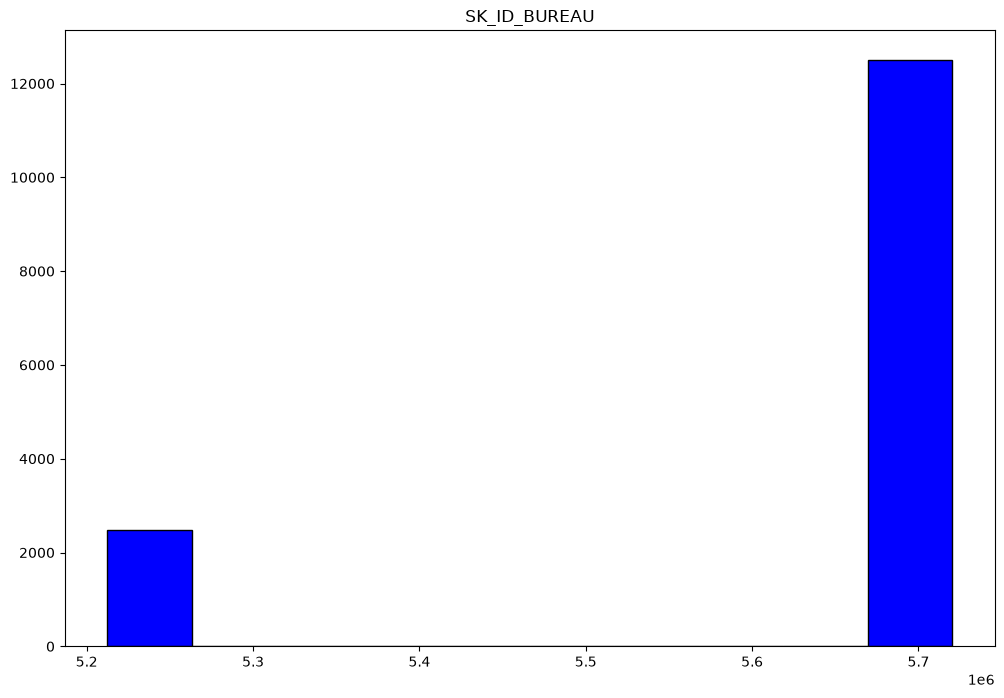

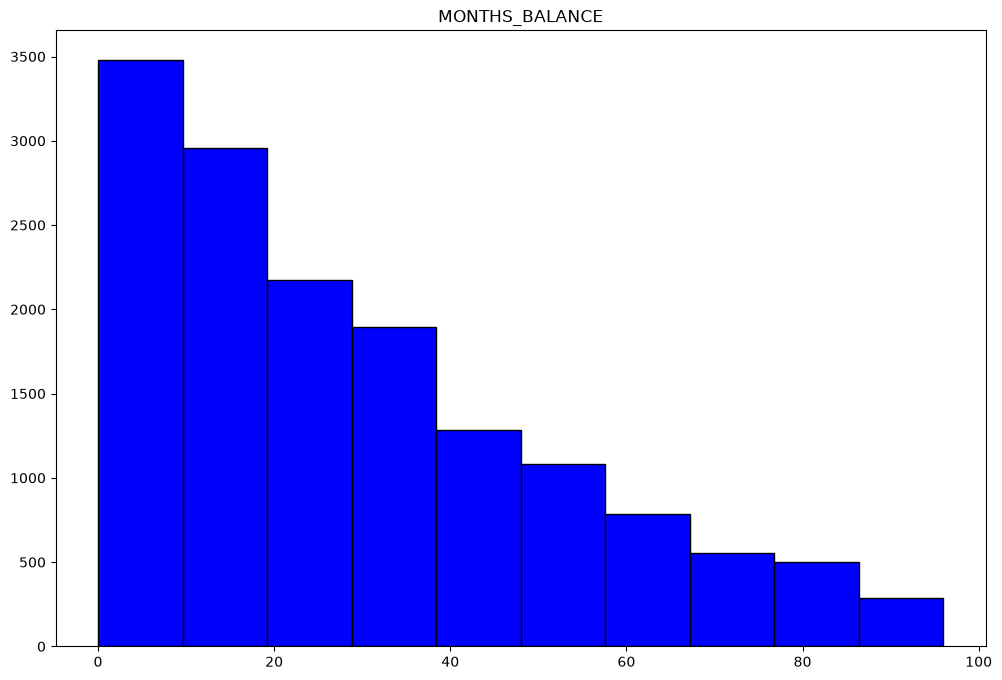

In [168]:
num_col_balance = df_balance.select_dtypes(include='number')
for num_bal in num_col_balance:
    plt.figure(figsize=(12,8))
    plt.title(f'{num_bal}')
    plt.hist(df_balance[num_bal], color='blue', edgecolor='black')
    plt.show()

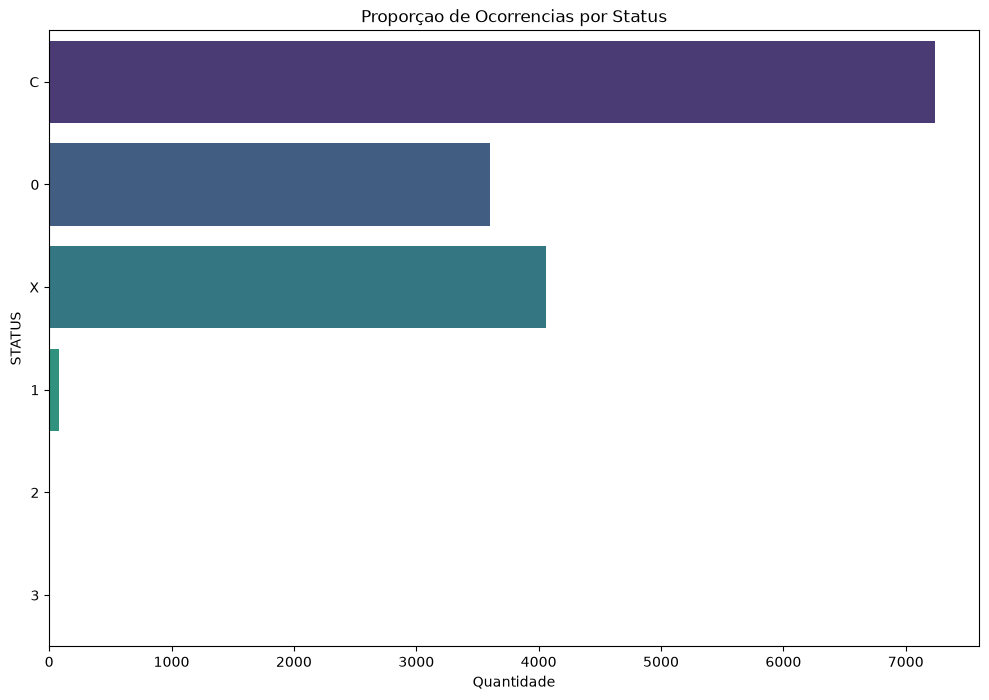

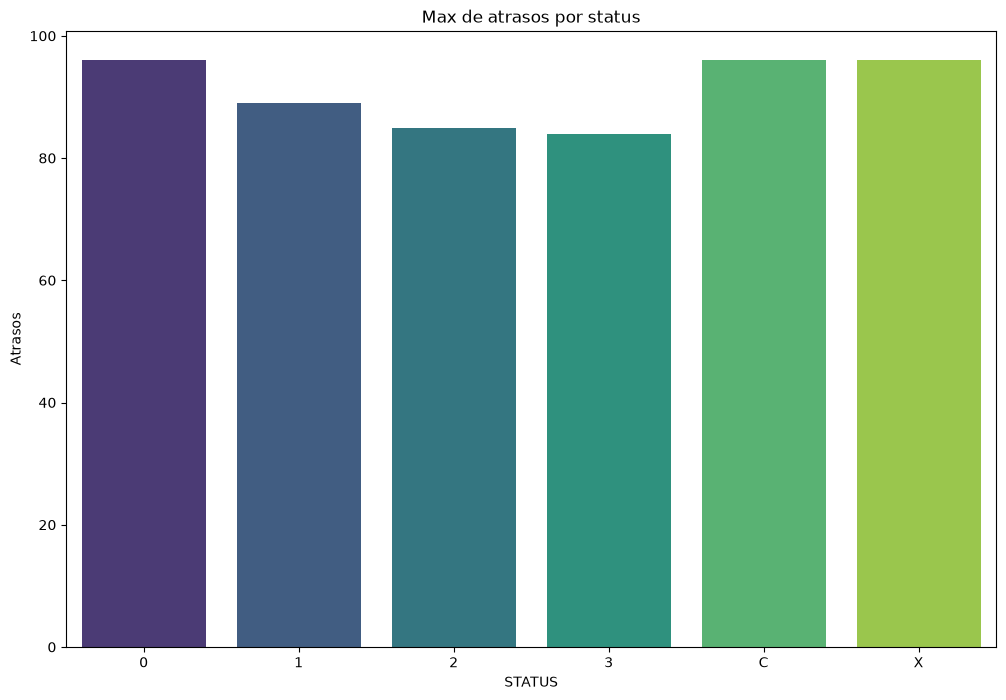

In [169]:
# filtrando id's com maior atraso e avaliando reputaçao 
filter = df_balance.groupby('STATUS')[['MONTHS_BALANCE']].max()

# plotando quantidade de ocorrencias por status
plt.figure(figsize=(12,8))
plt.title('Proporçao de Ocorrencias por Status')
sns.countplot(data=df_balance, y='STATUS', palette='viridis')
plt.xlabel('Quantidade')
plt.show()

# plotando filtro de maiores atrasos por status 
plt.figure(figsize=(12,8))
plt.title('Max de atrasos por status')
sns.barplot(data=filter, x='STATUS', y='MONTHS_BALANCE', palette='viridis')
plt.ylabel('Atrasos')
plt.show()


# Bureau 

In [170]:
df_bureau

,CONTAS_ATIVAS,MEDIA_ATRASO_DIAS,CREDIT_TYPE,CREDIT_ACTIVE
0,1,187,Another type of loan,Active
1,1,1007,Real estate loan,Active
2,1,986,Credit card,Bad debt
3,1,308,Loan for working capital replenishment,Closed
4,2,2661,Unknown type of loan,Closed
5,3,1463,Car loan,Sold
6,4,133,Loan for working capital replenishment,Active
7,4,1463,Mortgage,Sold
8,5,541,Another type of loan,Closed
9,8,2827,Loan for business development,Closed


desvio padrao: 1127.4725839101968
mediana: 33.33333333333333


CREDIT_TYPE,Another type of loan,Car loan,Consumer credit,Credit card,Loan for business development,Loan for working capital replenishment,Microloan,Mortgage,Real estate loan,Unknown type of loan
CONTAS_ATIVAS,3.0,77.666667,3582.333333,912.0,8.0,2.5,87.0,58.666667,1.0,2.0


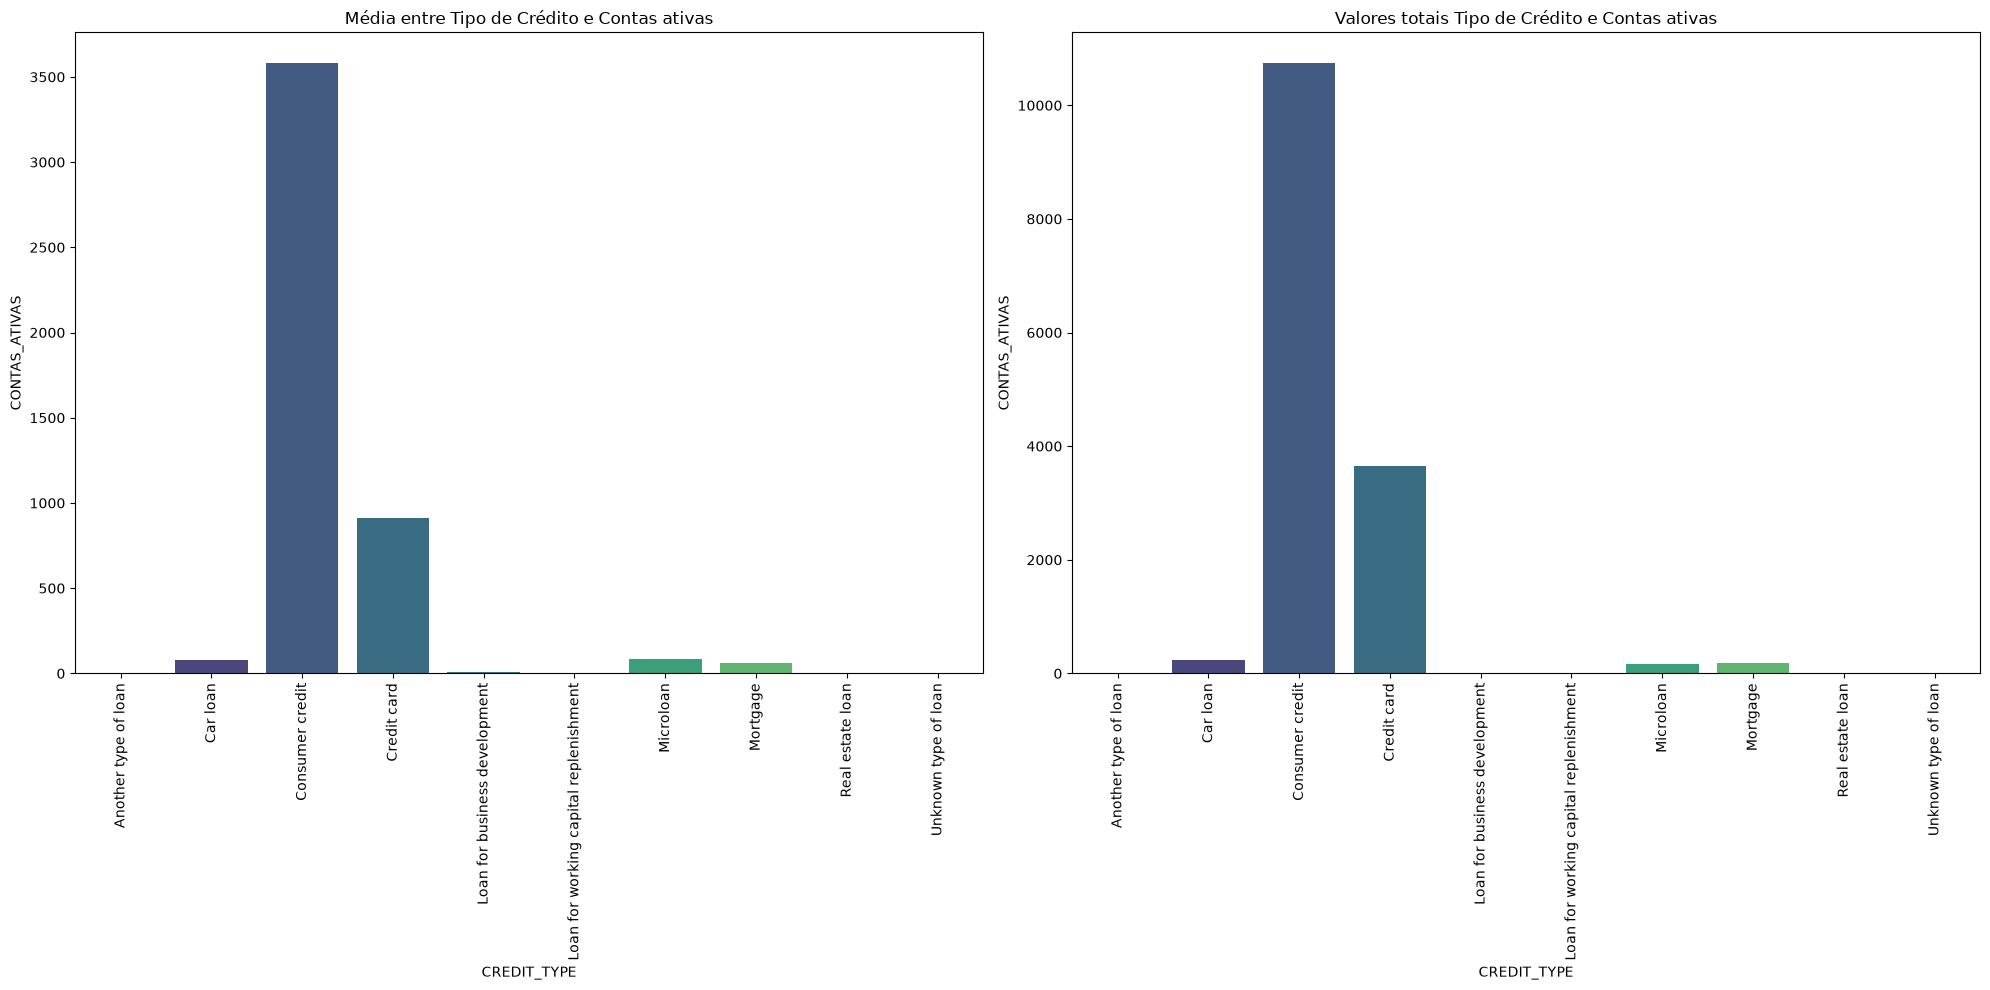

In [171]:
plot_groupby(df_bureau, 'CREDIT_TYPE', 'CONTAS_ATIVAS', 'Tipo de Crédito e Contas ativas').plot_mean()

desvio padrao: 940.017925730379
mediana: 948.375


CREDIT_TYPE,Another type of loan,Car loan,Consumer credit,Credit card,Loan for business development,Loan for working capital replenishment,Microloan,Mortgage,Real estate loan,Unknown type of loan
MEDIA_ATRASO_DIAS,364.0,1472.0,673.0,889.75,2827.0,220.5,188.0,1330.0,1007.0,2661.0


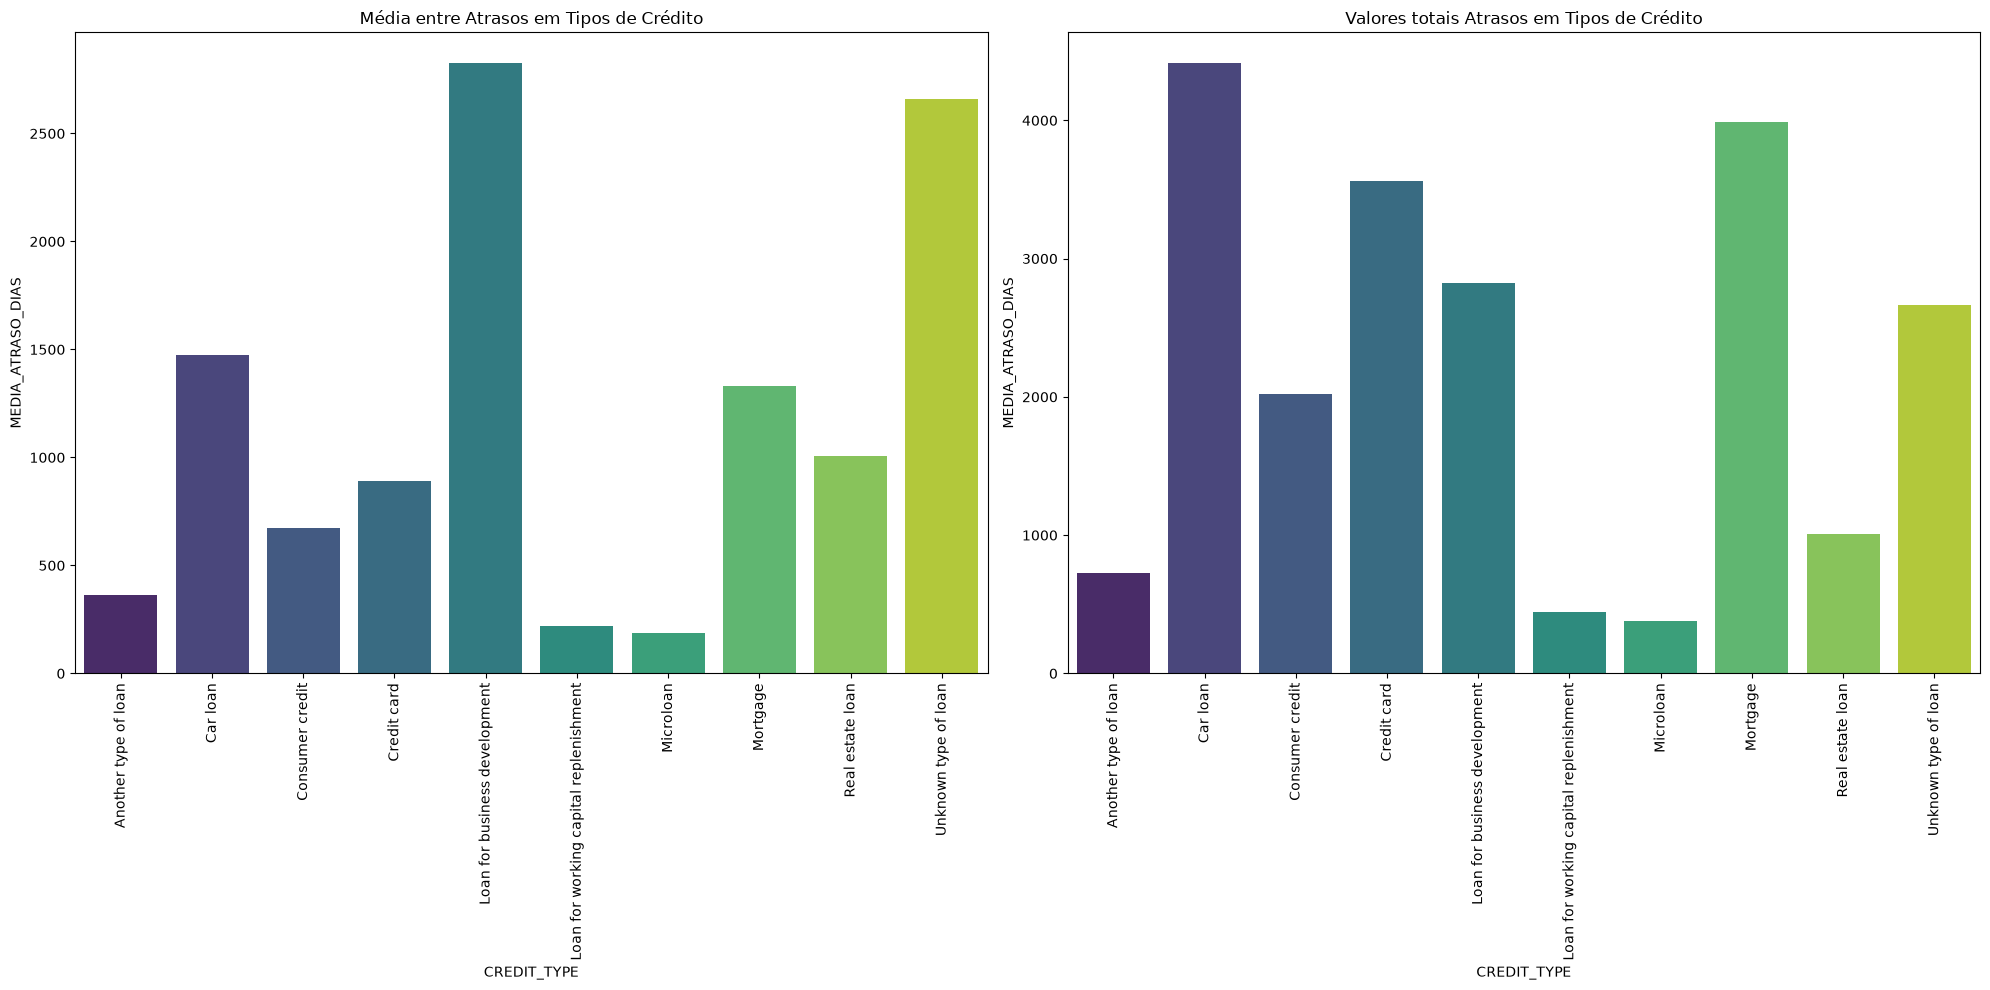

In [172]:
plot_groupby(df_bureau, 'CREDIT_TYPE', 'MEDIA_ATRASO_DIAS', 'Atrasos em Tipos de Crédito').plot_mean()

In [173]:
df_bureau

,CONTAS_ATIVAS,MEDIA_ATRASO_DIAS,CREDIT_TYPE,CREDIT_ACTIVE
0,1,187,Another type of loan,Active
1,1,1007,Real estate loan,Active
2,1,986,Credit card,Bad debt
3,1,308,Loan for working capital replenishment,Closed
4,2,2661,Unknown type of loan,Closed
5,3,1463,Car loan,Sold
6,4,133,Loan for working capital replenishment,Active
7,4,1463,Mortgage,Sold
8,5,541,Another type of loan,Closed
9,8,2827,Loan for business development,Closed


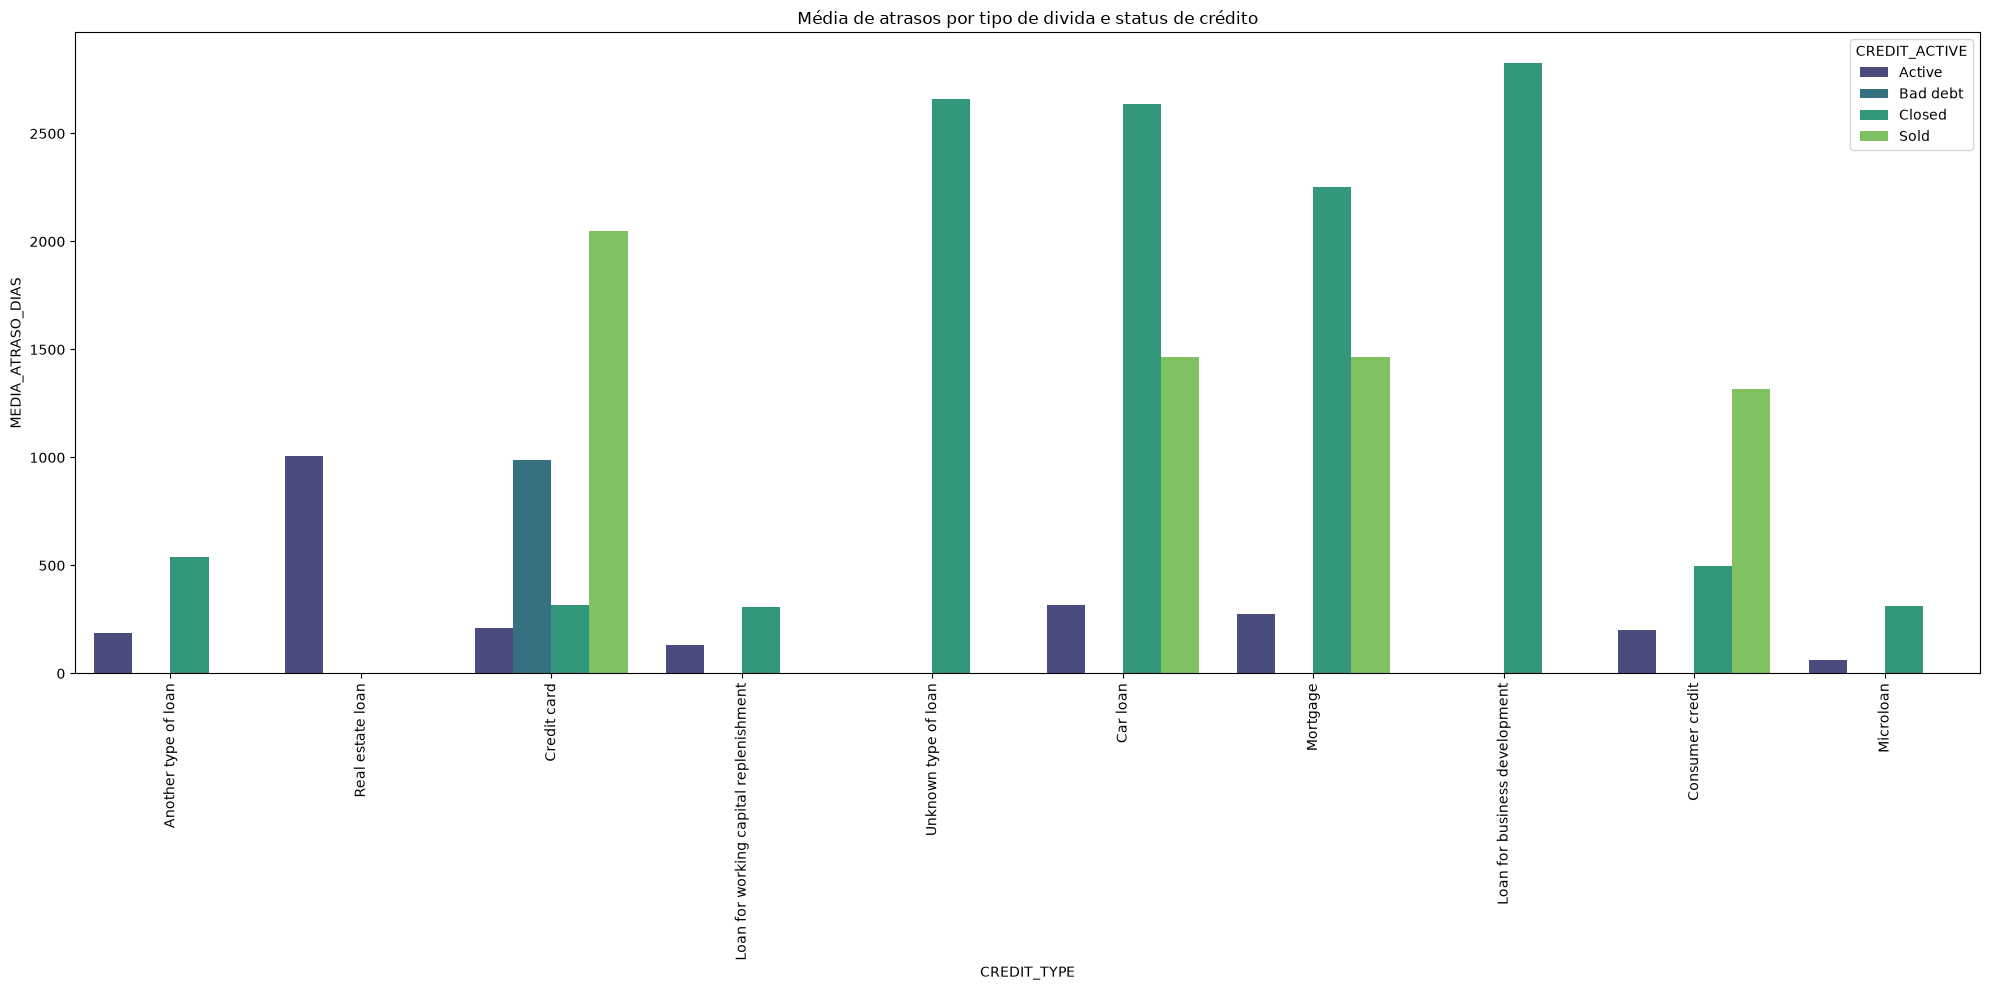

In [174]:
# plotar graficos Hue
hue_plot(df_bureau, 'CREDIT_TYPE', 'MEDIA_ATRASO_DIAS', 'CREDIT_ACTIVE', 'Média de atrasos por tipo de divida e status de crédito')

# Customers History

In [175]:
# mostrando tabela de clientes 
df_customers.head()

,SK_ID_CURR,TARGET,CODE_GENDER,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,age,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,100002,1,M,Cash loans,N,0,202500.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,25,Laborers,1.0,2,Business Entity Type 3
1,100003,0,F,Cash loans,N,0,270000.0,Family,State servant,Higher education,Married,45,Core staff,2.0,1,School
2,100004,0,M,Revolving loans,Y,0,67500.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,52,Laborers,1.0,2,Government
3,100006,0,F,Cash loans,N,0,135000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,52,Laborers,2.0,2,Business Entity Type 3
4,100007,0,M,Cash loans,N,0,121500.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,54,Core staff,1.0,2,Religion


In [176]:
# verificando nulos 
df_customers.isnull().sum()

SK_ID_CURR                 0
TARGET                     0
CODE_GENDER                0
NAME_CONTRACT_TYPE         0
FLAG_OWN_CAR               0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_TYPE_SUITE           61
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
age                        0
OCCUPATION_TYPE         4663
CNT_FAM_MEMBERS            0
REGION_RATING_CLIENT       0
ORGANIZATION_TYPE          0
dtype: int64

In [177]:
# dropando coluna OCCUPATION_TYPE, pois representa grande parte da amostra 
df_customers = df_customers.drop('OCCUPATION_TYPE', axis=1)

In [178]:
# dropando parte insignificante de nulos 
df_customers = df_customers.dropna()

In [179]:
# separando tipos de dados 
cat_customers = df_customers.select_dtypes(exclude='number').columns 
num_customers = df_customers.select_dtypes(include='number')

In [180]:
print(f'colunas categoricas: {cat_customers}') 
print()
print(f'colunas numericas: {num_customers.columns}')

colunas categoricas: Index(['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'ORGANIZATION_TYPE'],
      dtype='str')

colunas numericas: Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'age',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT'],
      dtype='str')


In [181]:
# estatistica das colunas numericas 
num_customers.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,14939.0,108742.707611,5044.934804,100002.0,104372.5,108748.0,113104.5,117513.0
TARGET,14939.0,0.078452,0.268891,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,14939.0,0.420108,0.724058,0.0,0.0,0.0,1.0,8.0
AMT_INCOME_TOTAL,14939.0,175472.088198,960660.423271,25650.0,112500.0,144000.0,202500.0,117000000.0
age,14939.0,43.336903,11.900594,21.0,33.0,43.0,53.0,68.0
CNT_FAM_MEMBERS,14939.0,2.165339,0.906737,1.0,2.0,2.0,3.0,10.0
REGION_RATING_CLIENT,14939.0,2.051543,0.510455,1.0,2.0,2.0,2.0,3.0


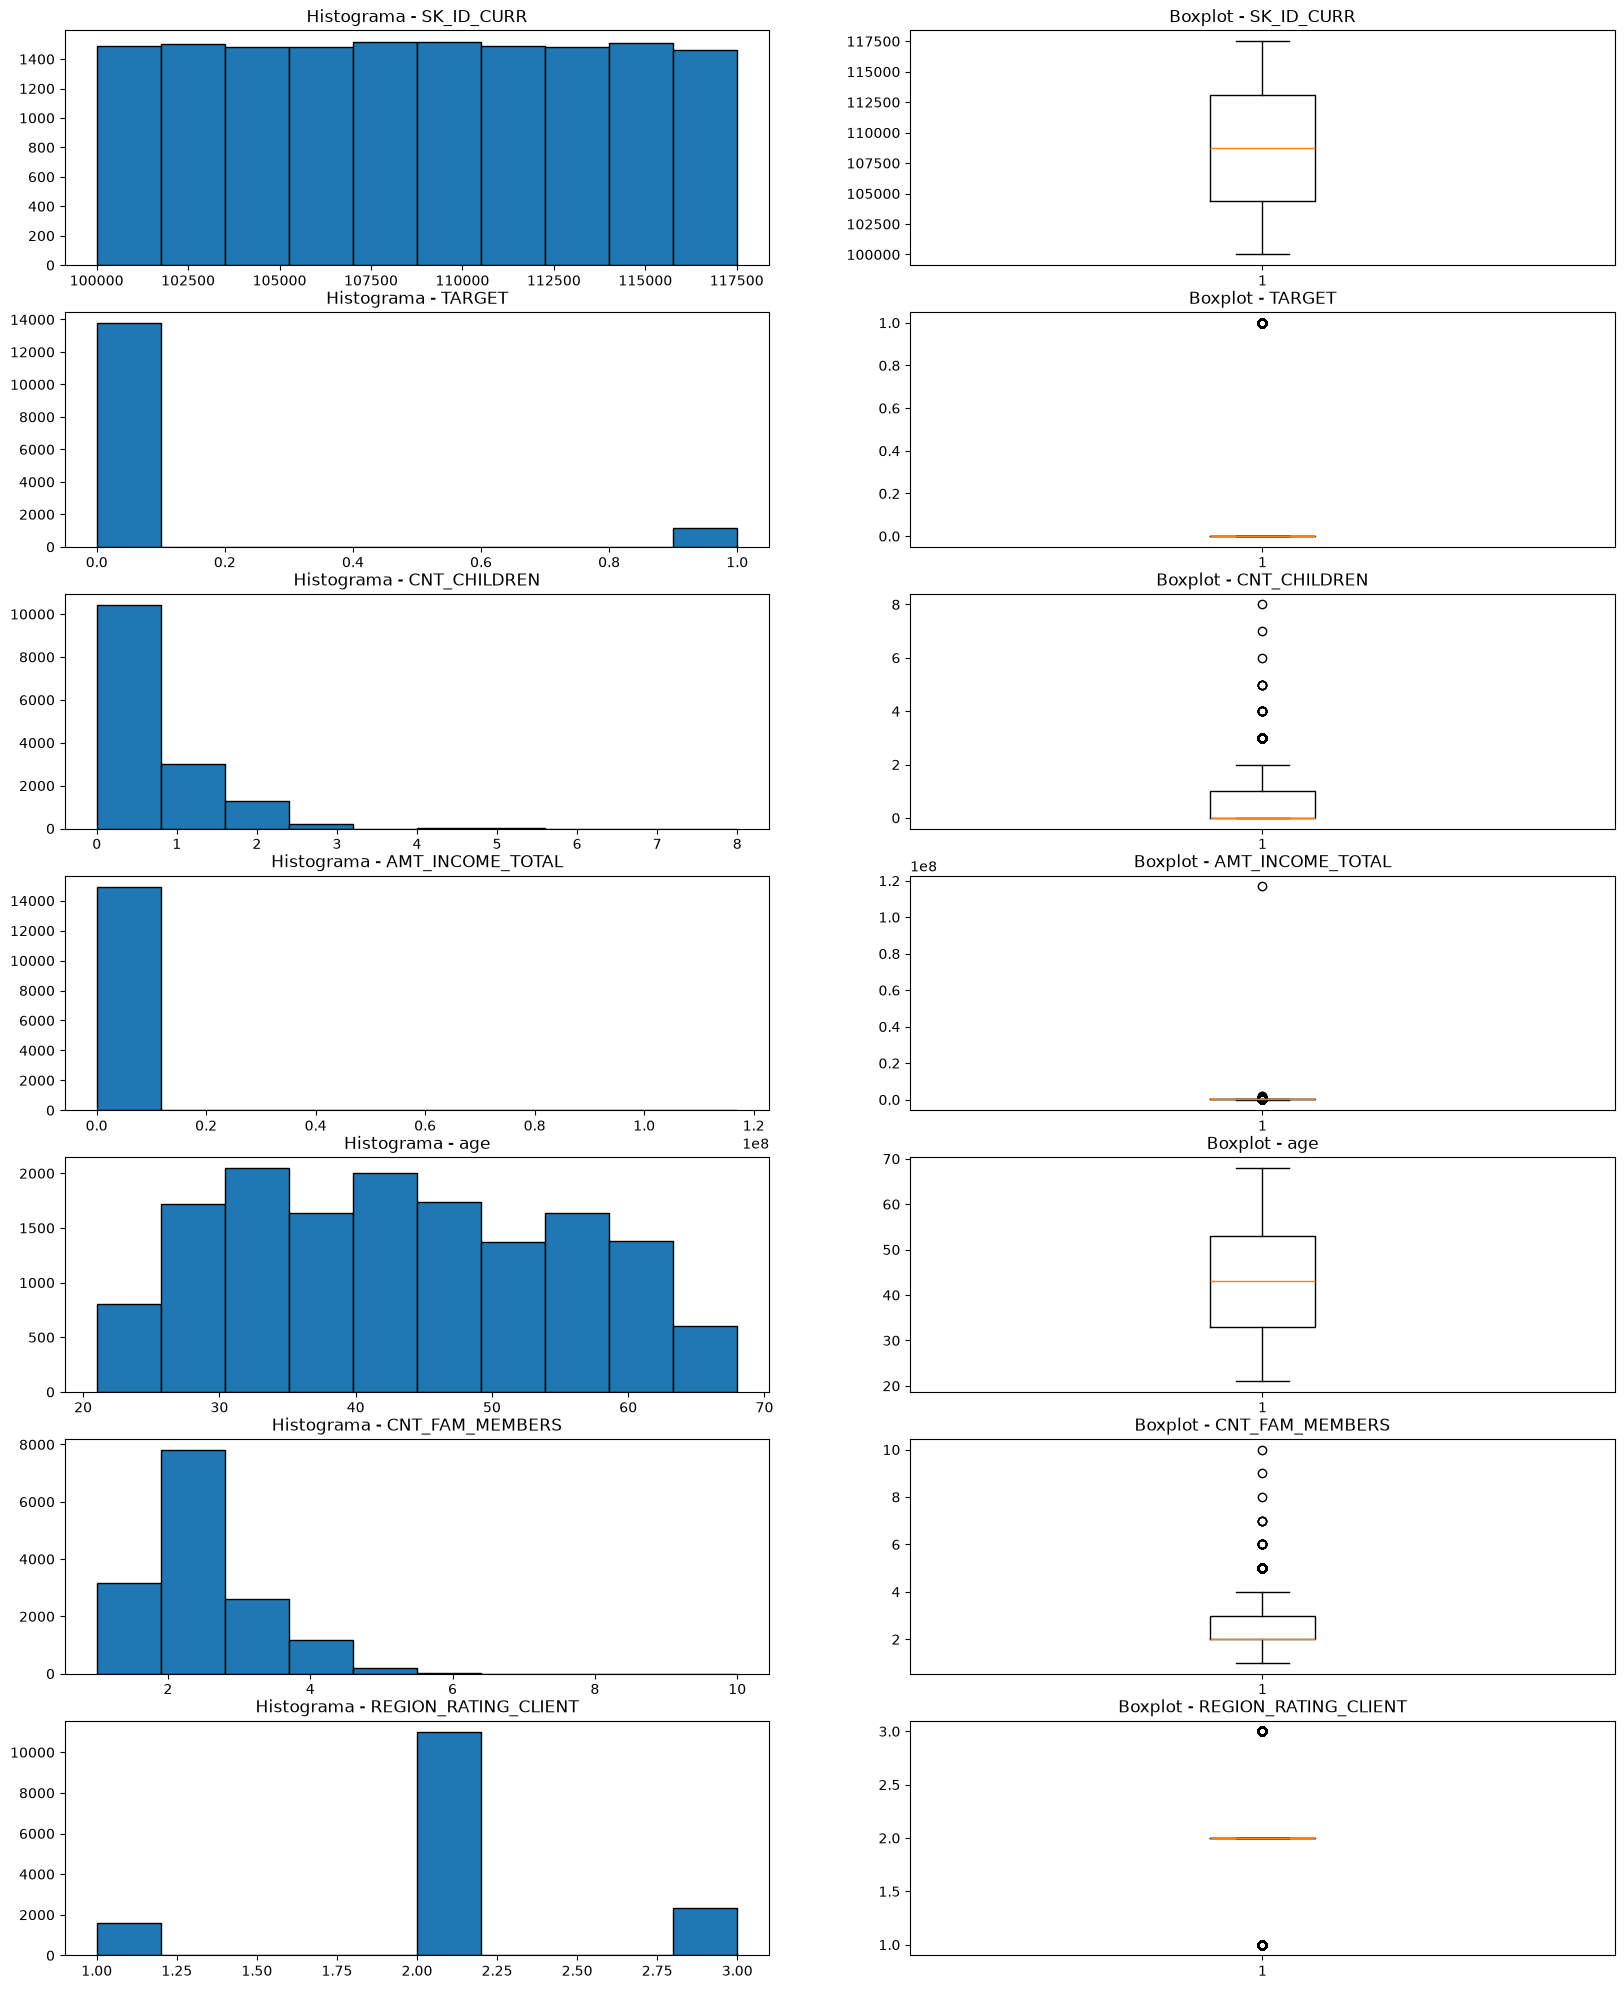

In [182]:
# verificando distribuiçoes dos dados 
fig, axes = plt.subplots(ncols=2, nrows=len(num_customers.columns), figsize=(20,25))
for i, num in enumerate(num_customers.columns): 
    axes[i, 0].hist(df_customers[num], edgecolor='black')
    axes[i, 0].set_title(f'Histograma - {num}')
    axes[i, 1].boxplot(df_customers[num])
    axes[i, 1].set_title(f'Boxplot - {num}') 

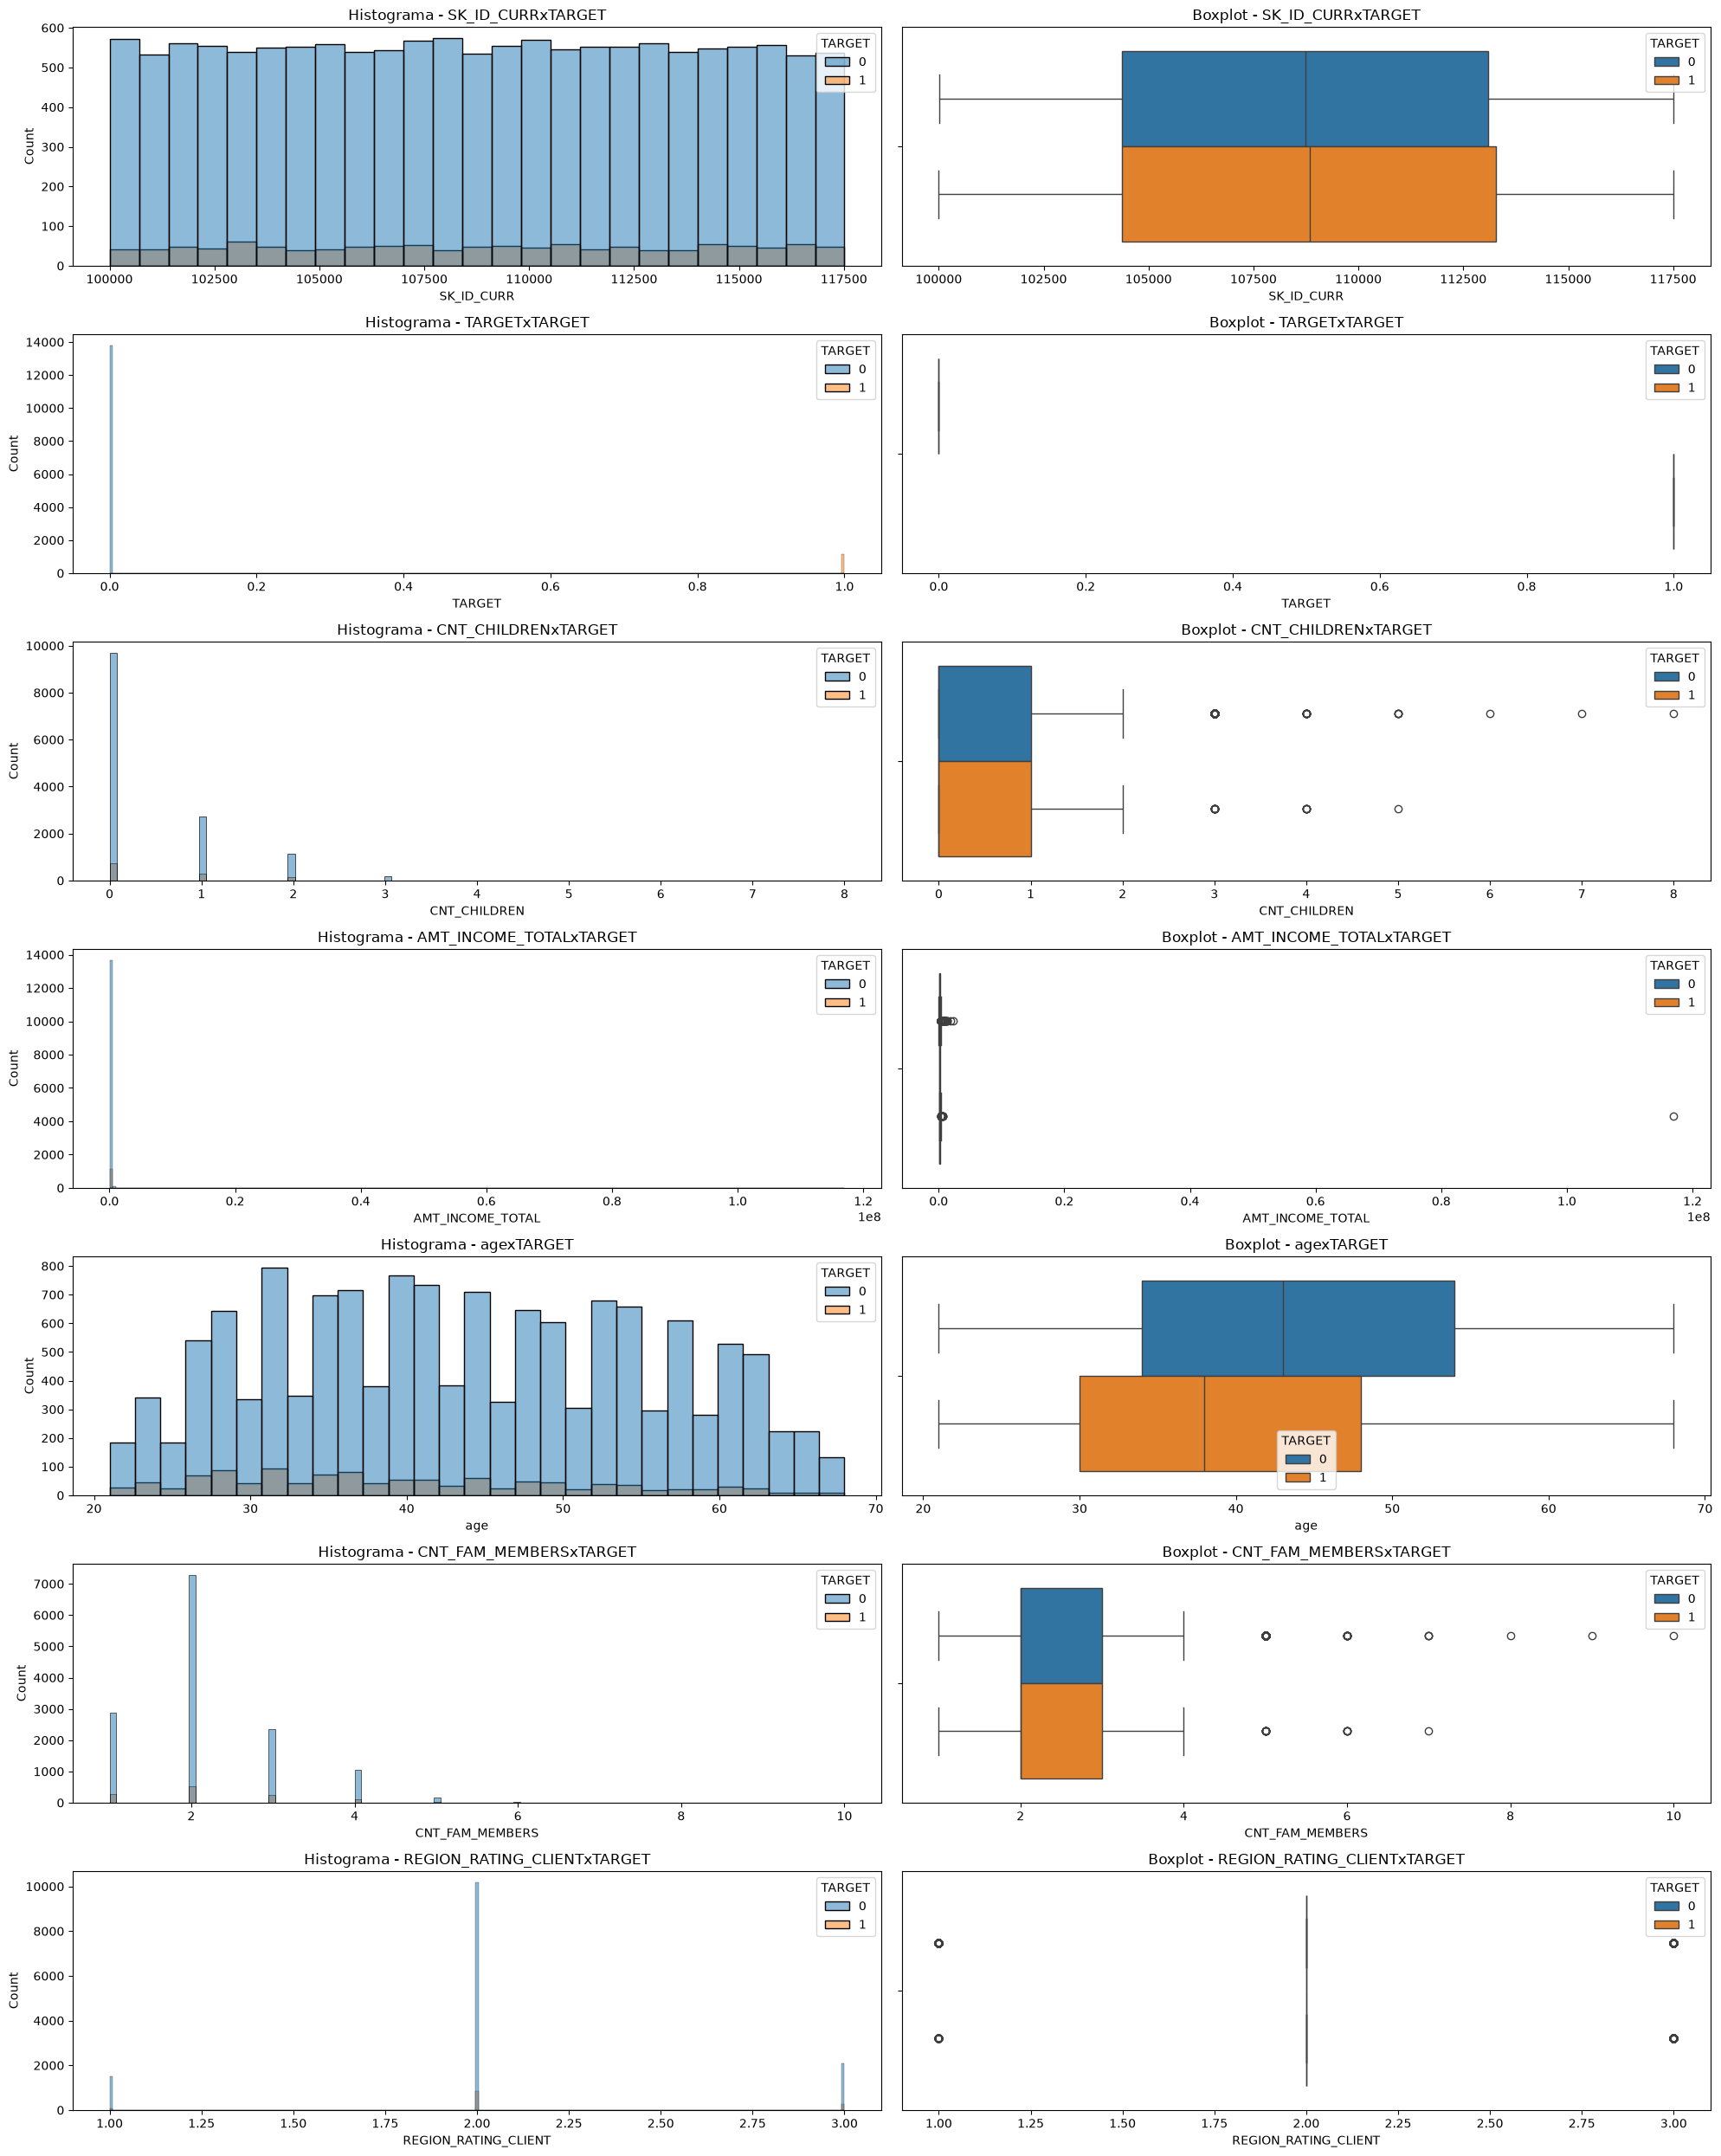

In [183]:
# verificando distribuiçao em relaçao ao target 
hist_plot(num_customers, 'TARGET')

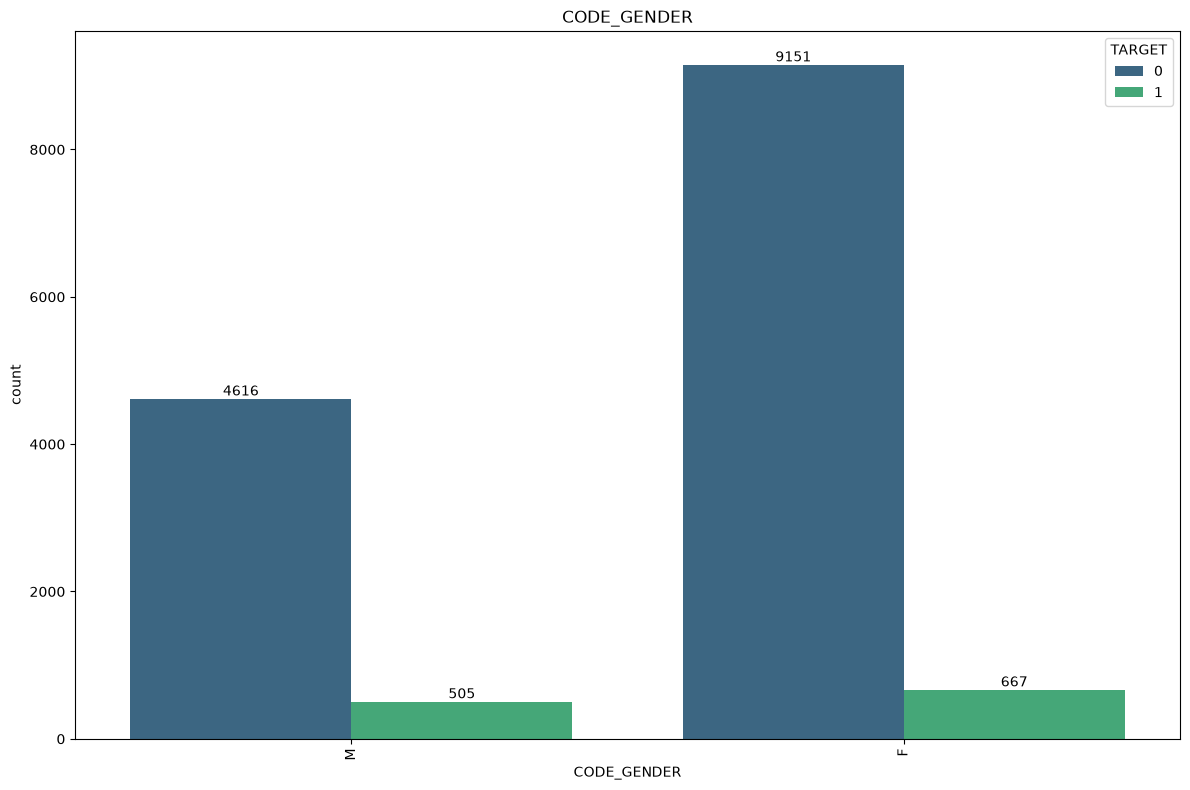

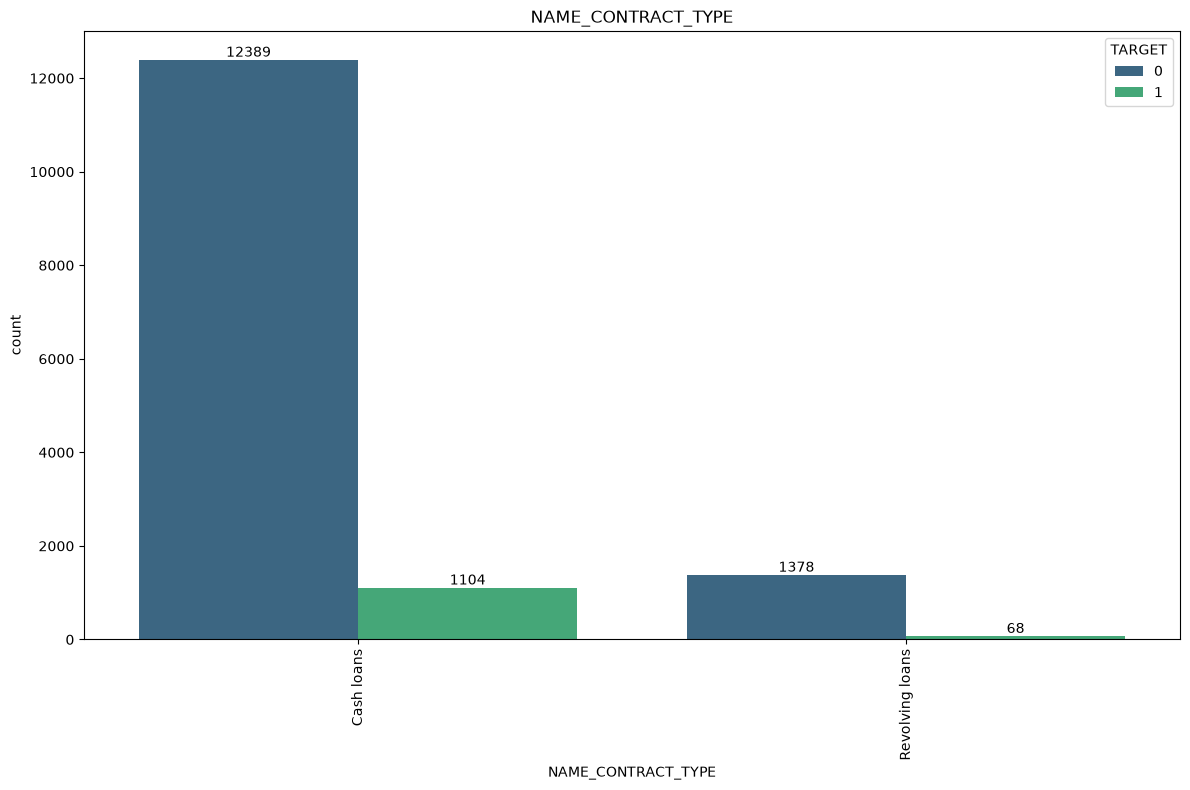

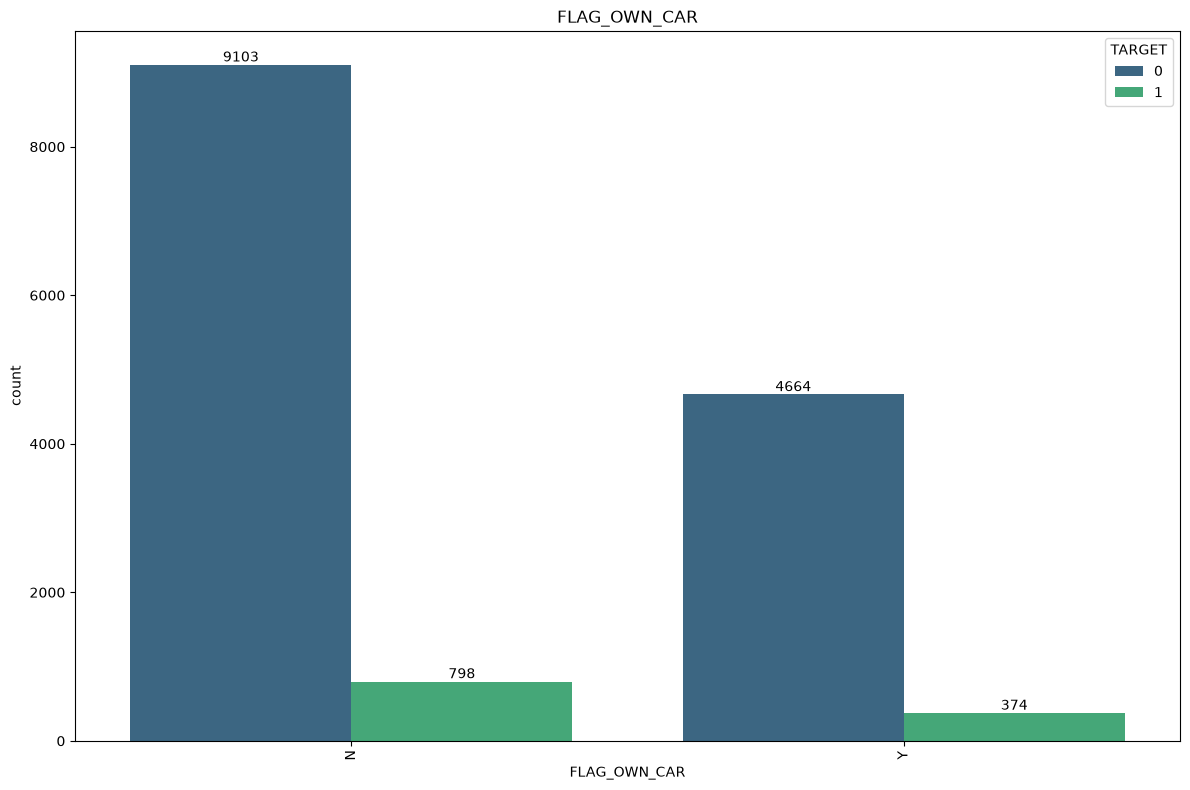

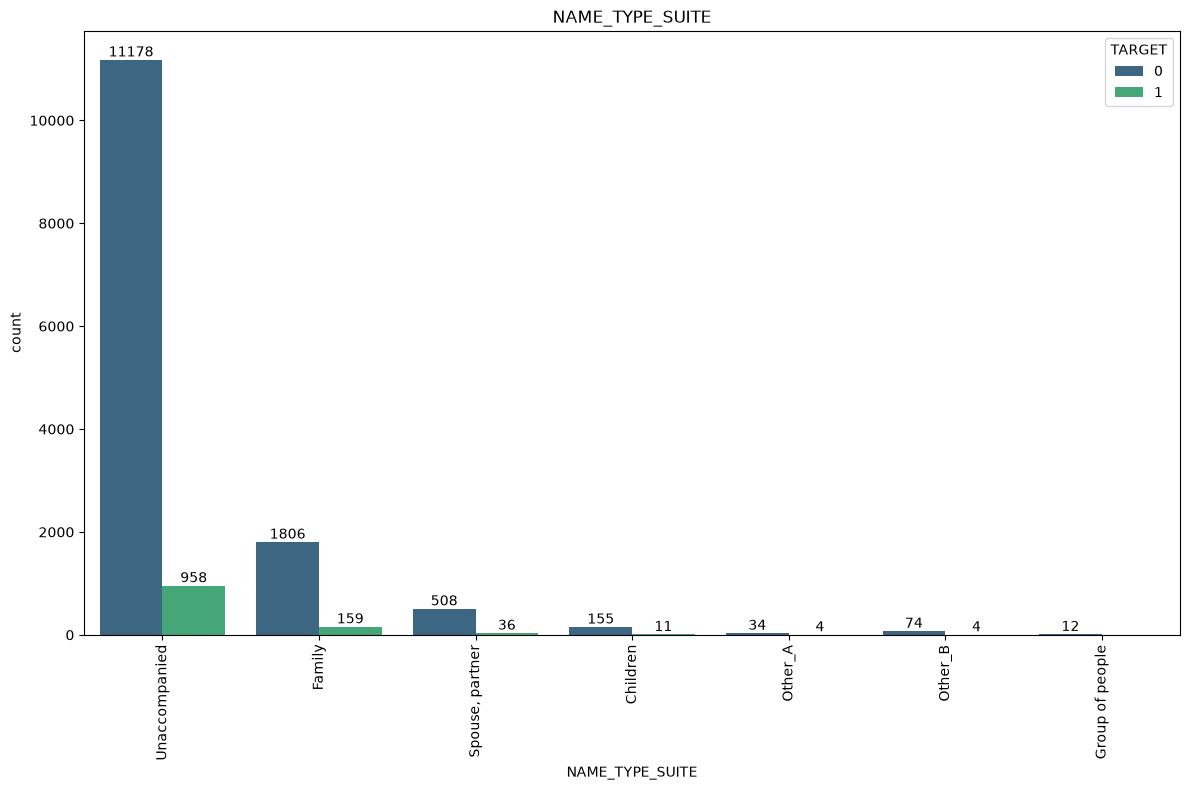

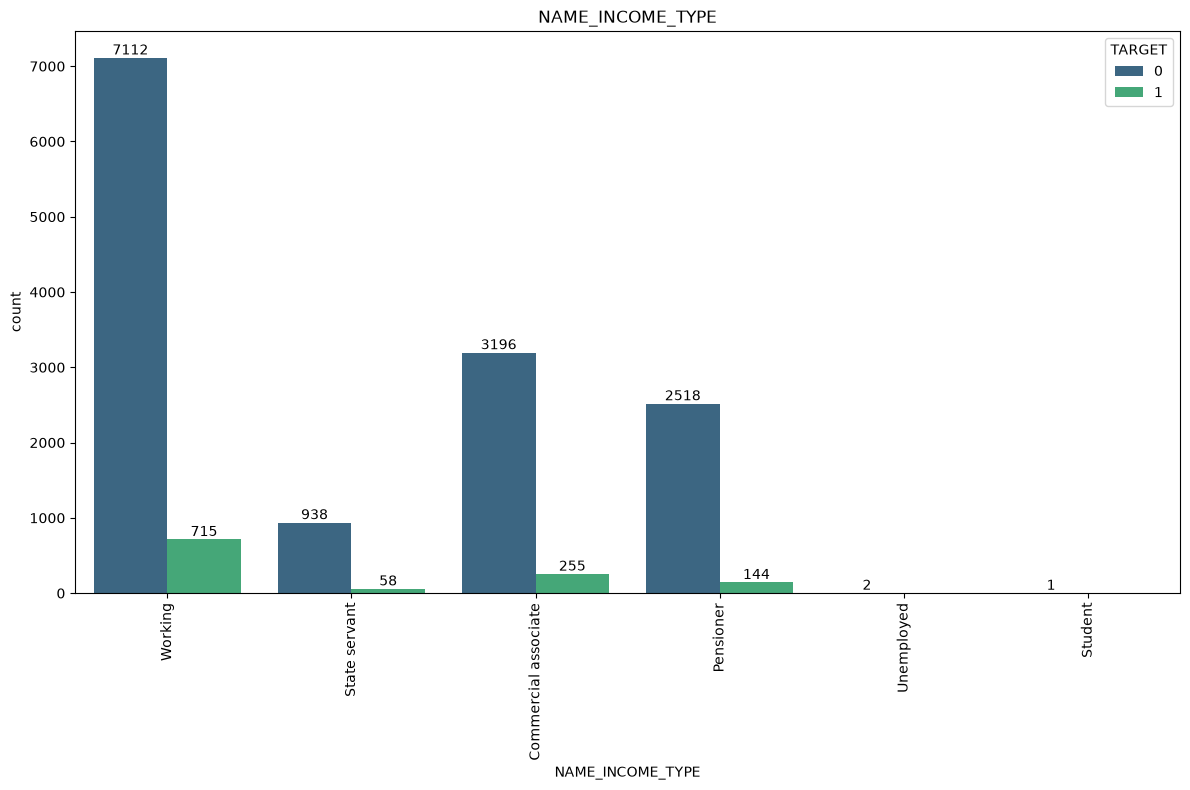

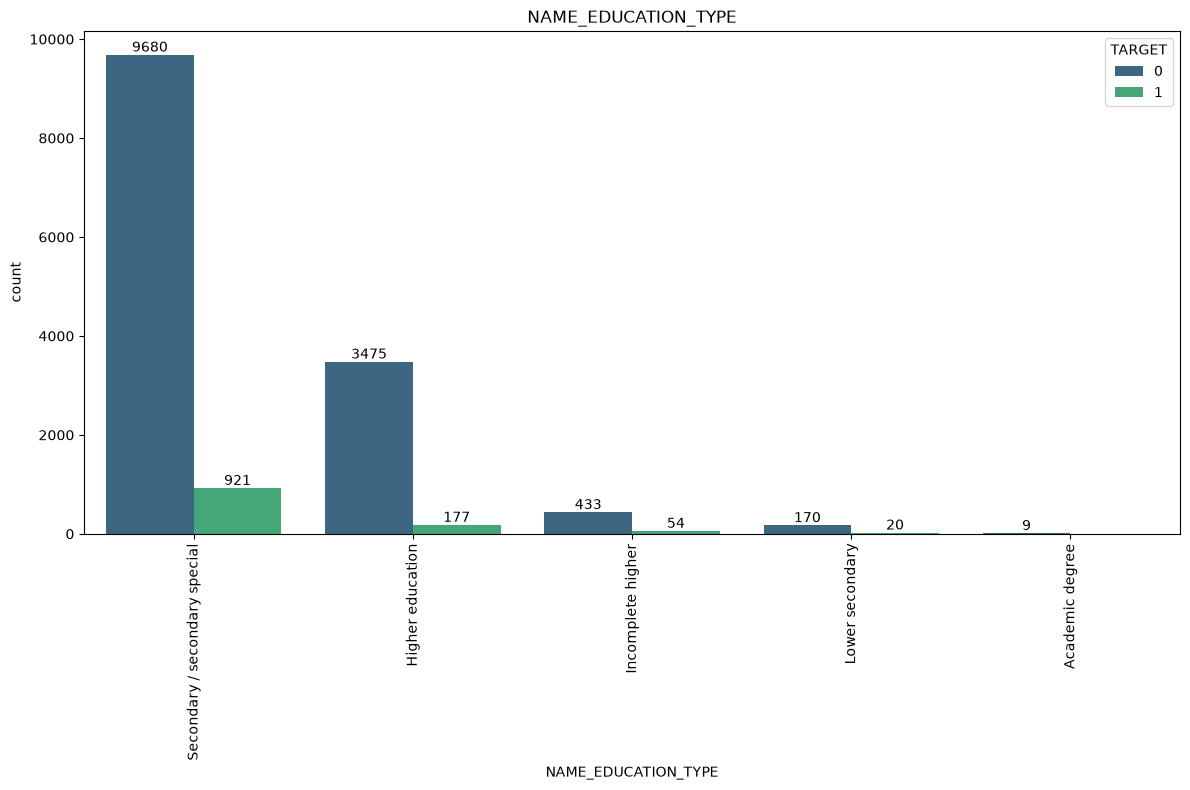

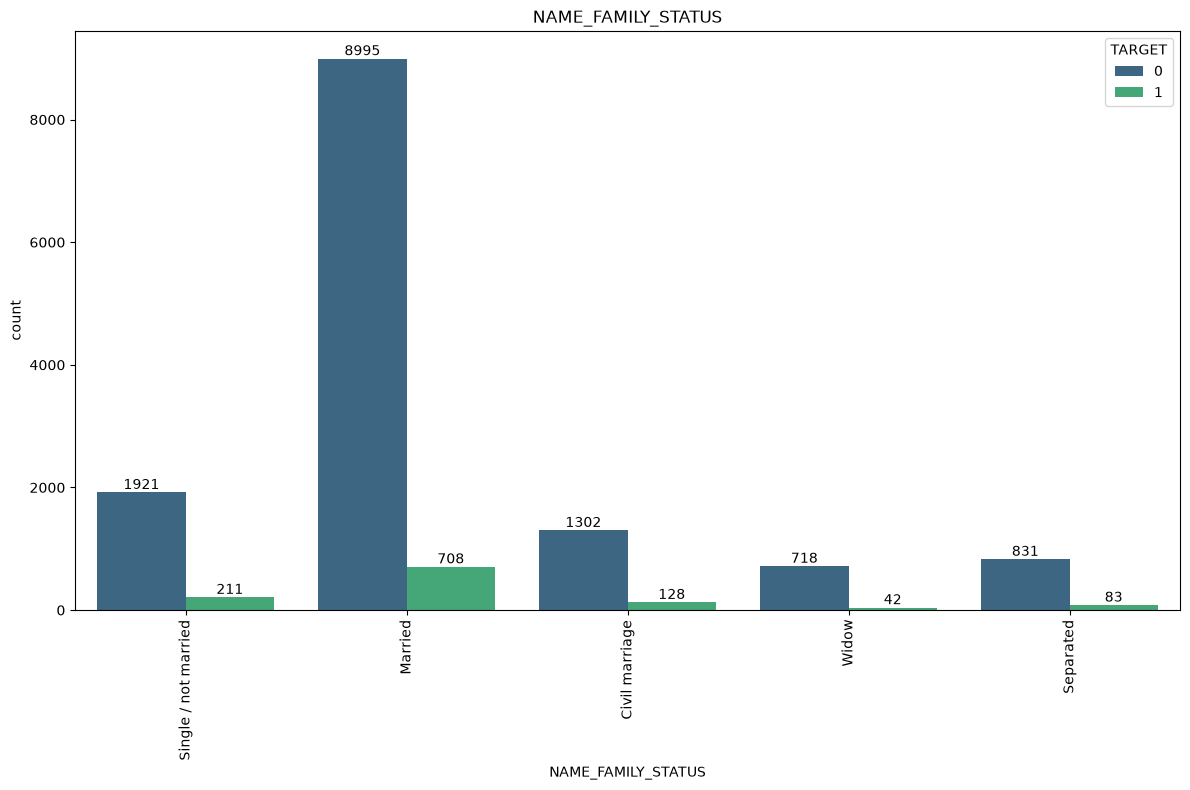

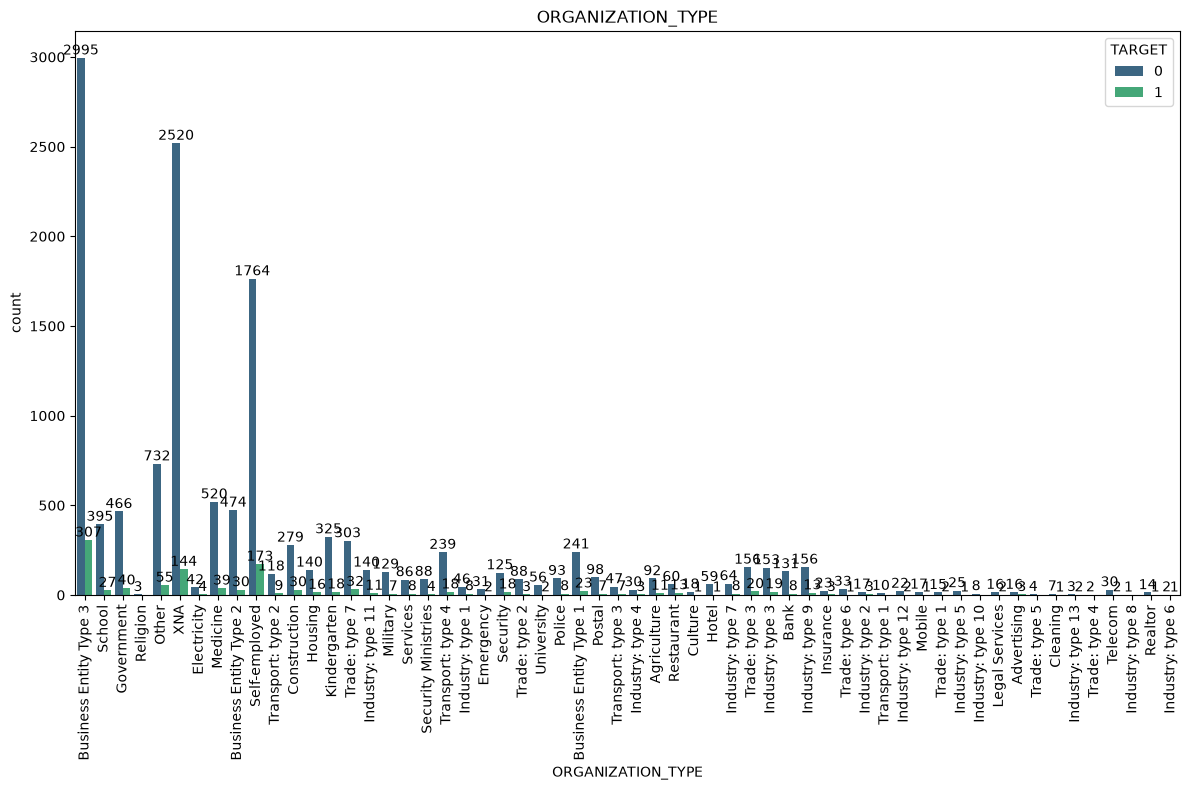

In [184]:
# verificando defaults em dados categoricos 
for cat in cat_customers:
    plt.figure(figsize=(12,8))
    plt.title(f'{cat}')
    ax = sns.countplot(data=df_customers, x=df_customers[cat], hue='TARGET', palette='viridis')
    plt.xticks(rotation=90)
    for container in ax.containers:
        ax.bar_label(container, fontsize=10)
    plt.tight_layout()
    plt.show()

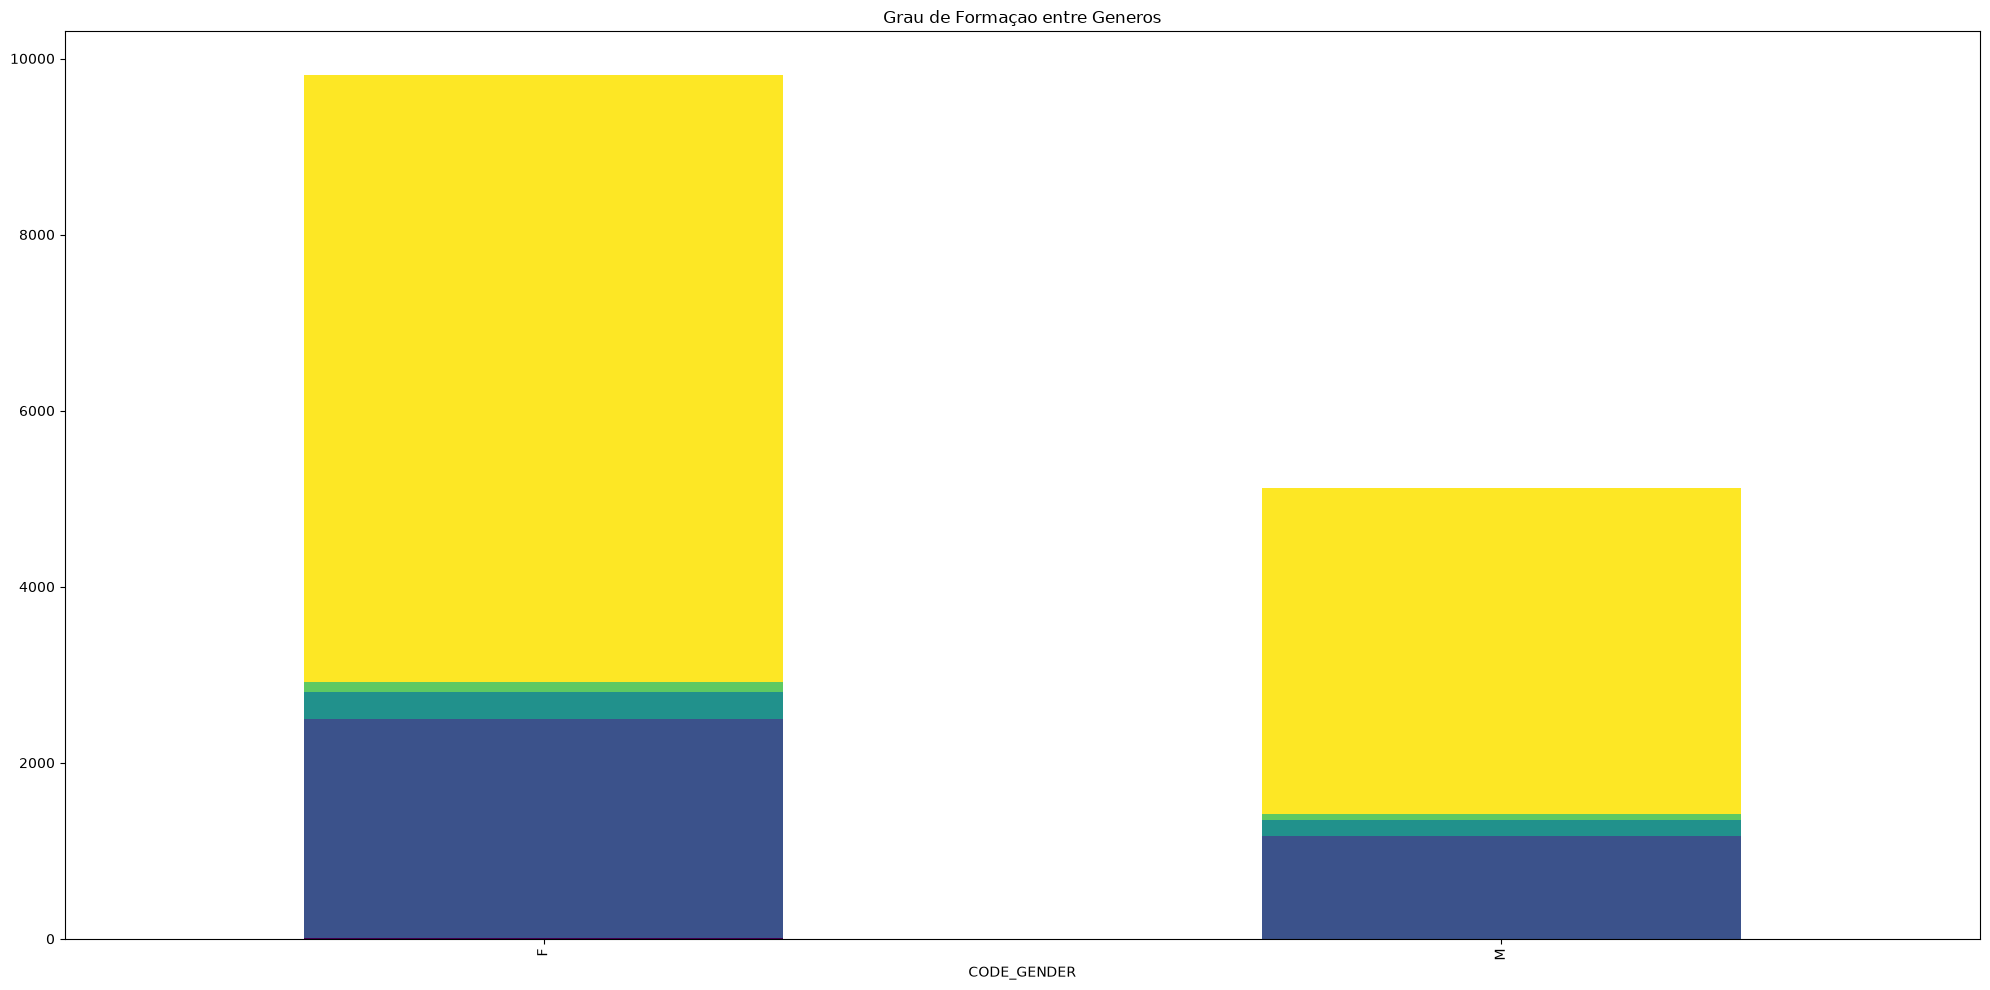

CODE_GENDER                       F                                     \
NAME_EDUCATION_TYPE Academic degree Higher education Incomplete higher   
CODE_GENDER                       7             2489               303   

CODE_GENDER                                                        \
NAME_EDUCATION_TYPE Lower secondary Secondary / secondary special   
CODE_GENDER                     118                          6901   

CODE_GENDER                       M                                     \
NAME_EDUCATION_TYPE Academic degree Higher education Incomplete higher   
CODE_GENDER                       2             1163               184   

CODE_GENDER                                                        
NAME_EDUCATION_TYPE Lower secondary Secondary / secondary special  
CODE_GENDER                      72                          3700

In [185]:
# verificando grau de formaçao entre generos
plot_groupby(df_customers, 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'Grau de Formaçao entre Generos').agg_groupby('CODE_GENDER')

desvio padrao: 0.061270721107528806
mediana: 0.43373032026069147


CODE_GENDER,F,M
CNT_CHILDREN,0.390405,0.477055


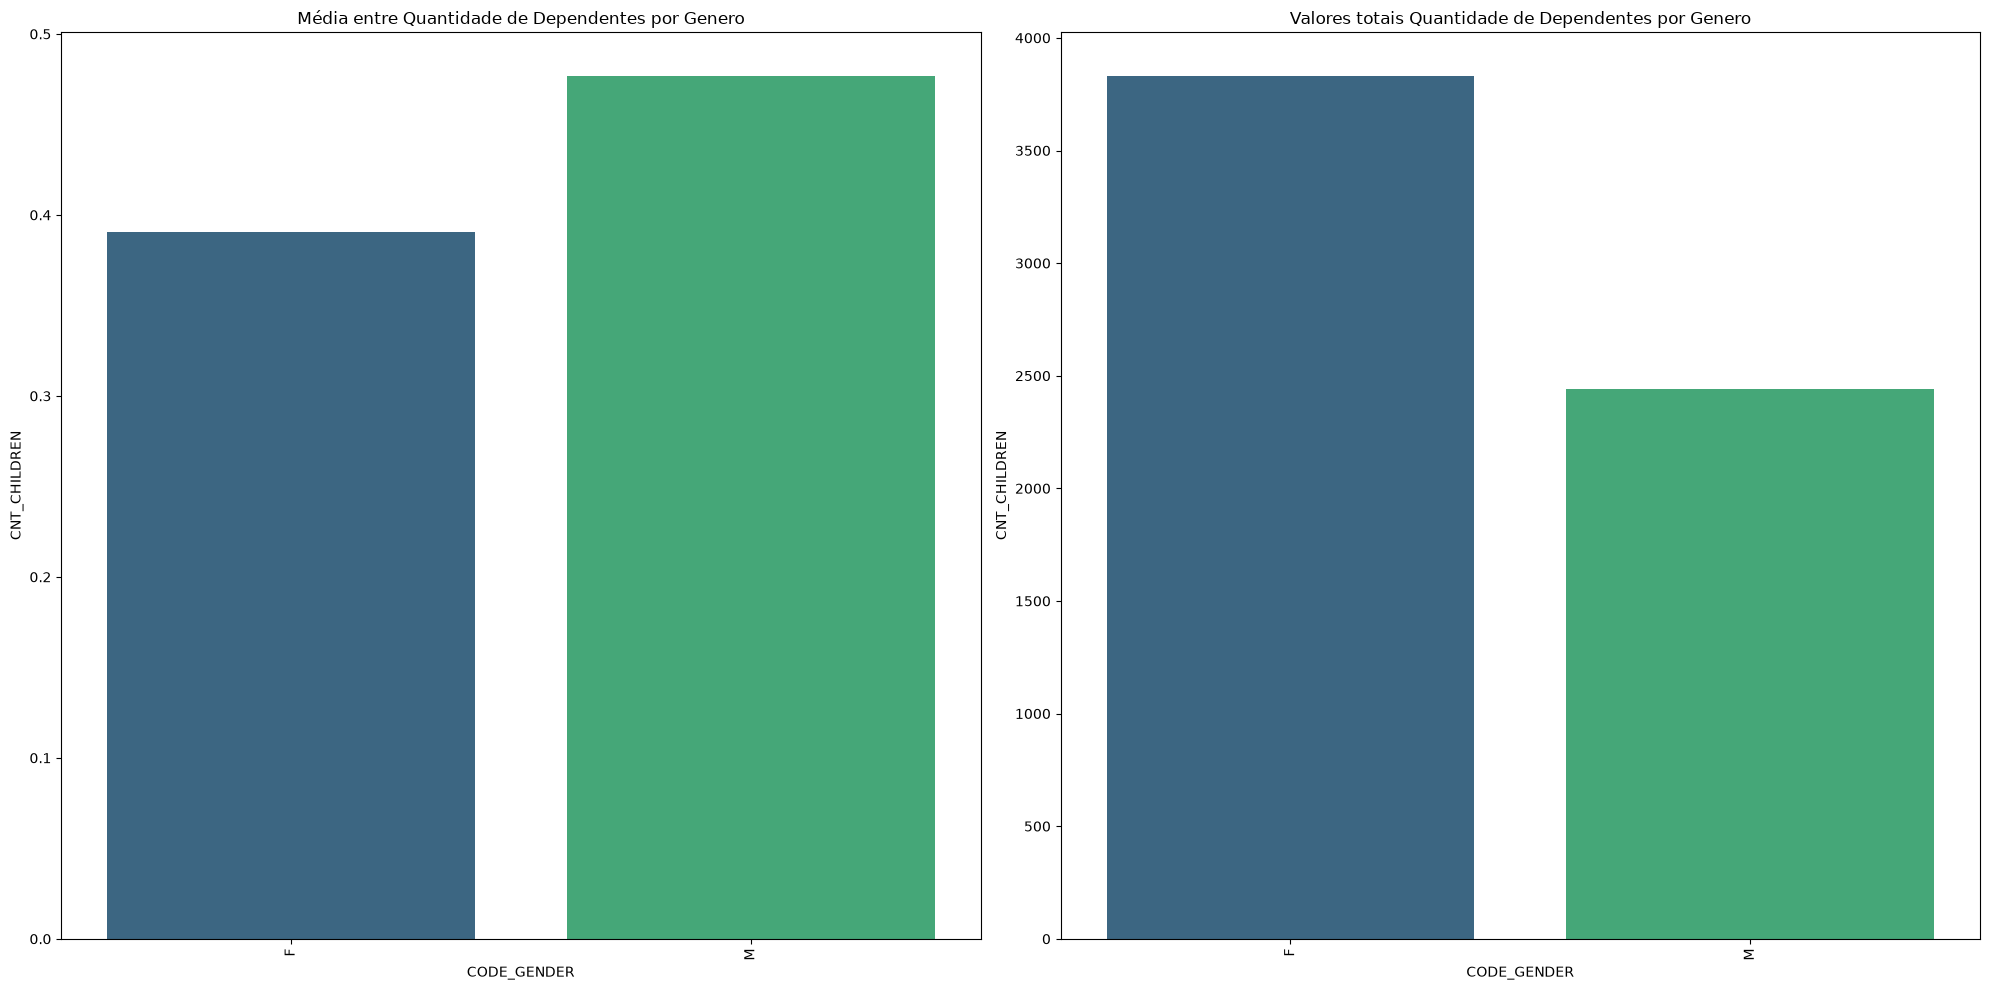

In [186]:
# verificando, por genero, quantidade de filhos 
plot_groupby(df_customers, 'CODE_GENDER', 'CNT_CHILDREN', 'Quantidade de Dependentes por Genero').plot_mean()

desvio padrao: 0.10478770415854952
mediana: 0.075


CNT_CHILDREN,0,1,2,3,4,5,6,7,8
TARGET,0.071648,0.09112,0.100946,0.075,0.315789,0.2,0.0,0.0,0.0


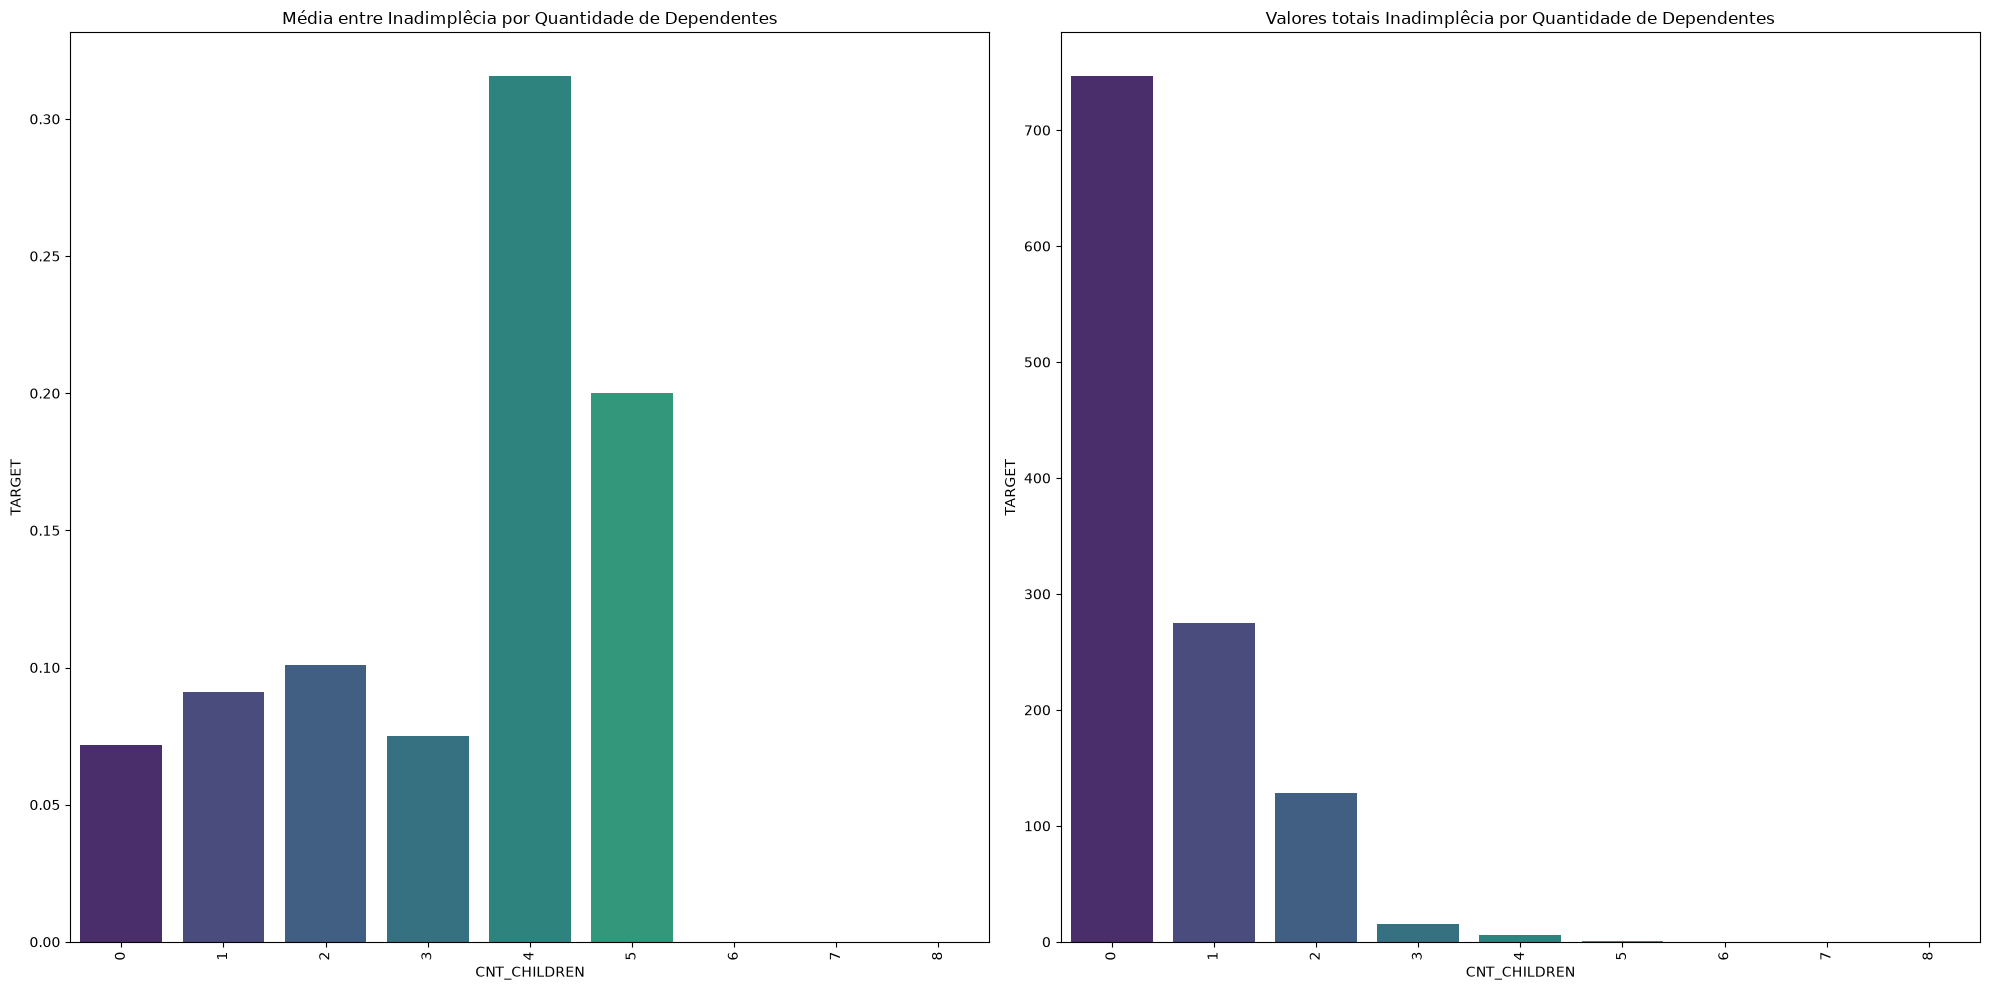

In [187]:
# verificando inadimplencia pela quantidade de dependentes 
plot_groupby(df_customers, 'CNT_CHILDREN', 'TARGET', 'Inadimplêcia por Quantidade de Dependentes').plot_mean()

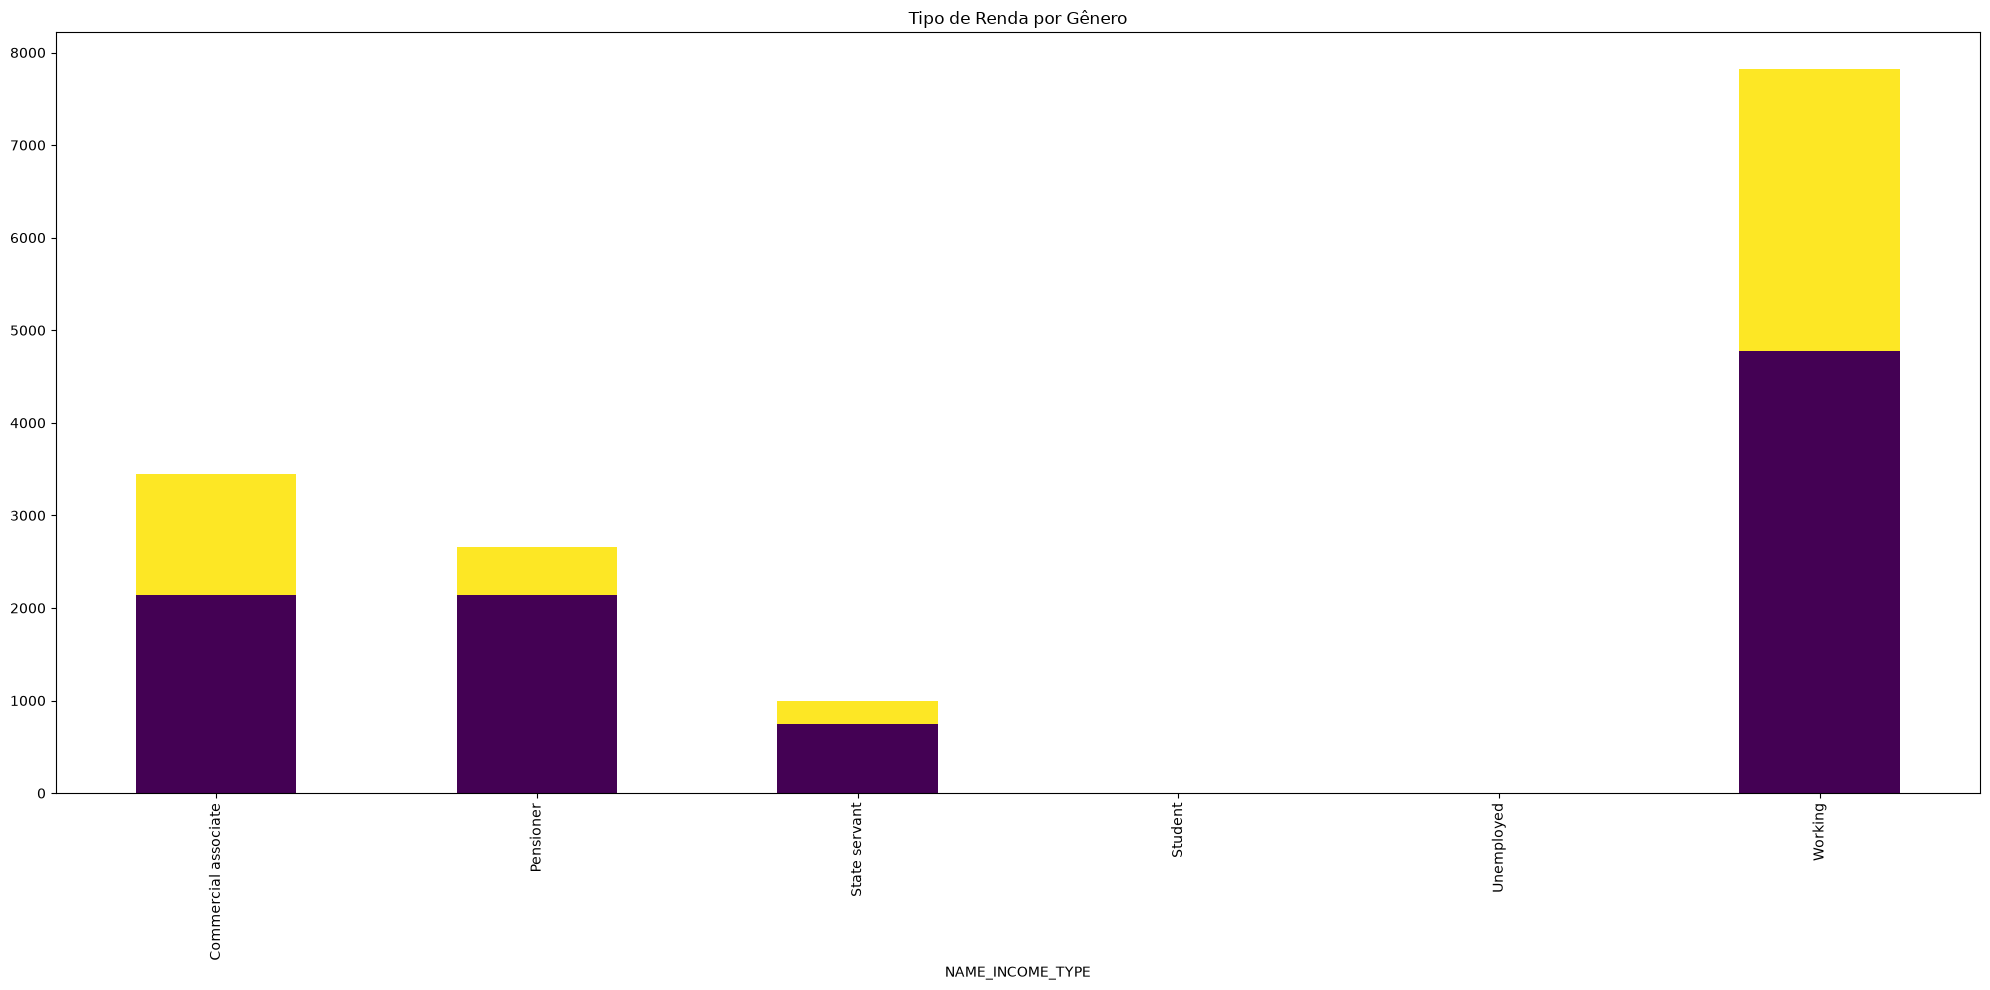

NAME_INCOME_TYPE Commercial associate       Pensioner      State servant       \
CODE_GENDER                         F     M         F    M             F    M   
NAME_INCOME_TYPE                 2143  1308      2145  517           752  244   

NAME_INCOME_TYPE Student Unemployed Working        
CODE_GENDER            M          F       F     M  
NAME_INCOME_TYPE       1          2    4776  3051

In [188]:
# verificando tipo de RENDA por genero 
plot_groupby(df_customers, 'NAME_INCOME_TYPE', 'CODE_GENDER', 'Tipo de Renda por Gênero').agg_groupby('NAME_INCOME_TYPE')

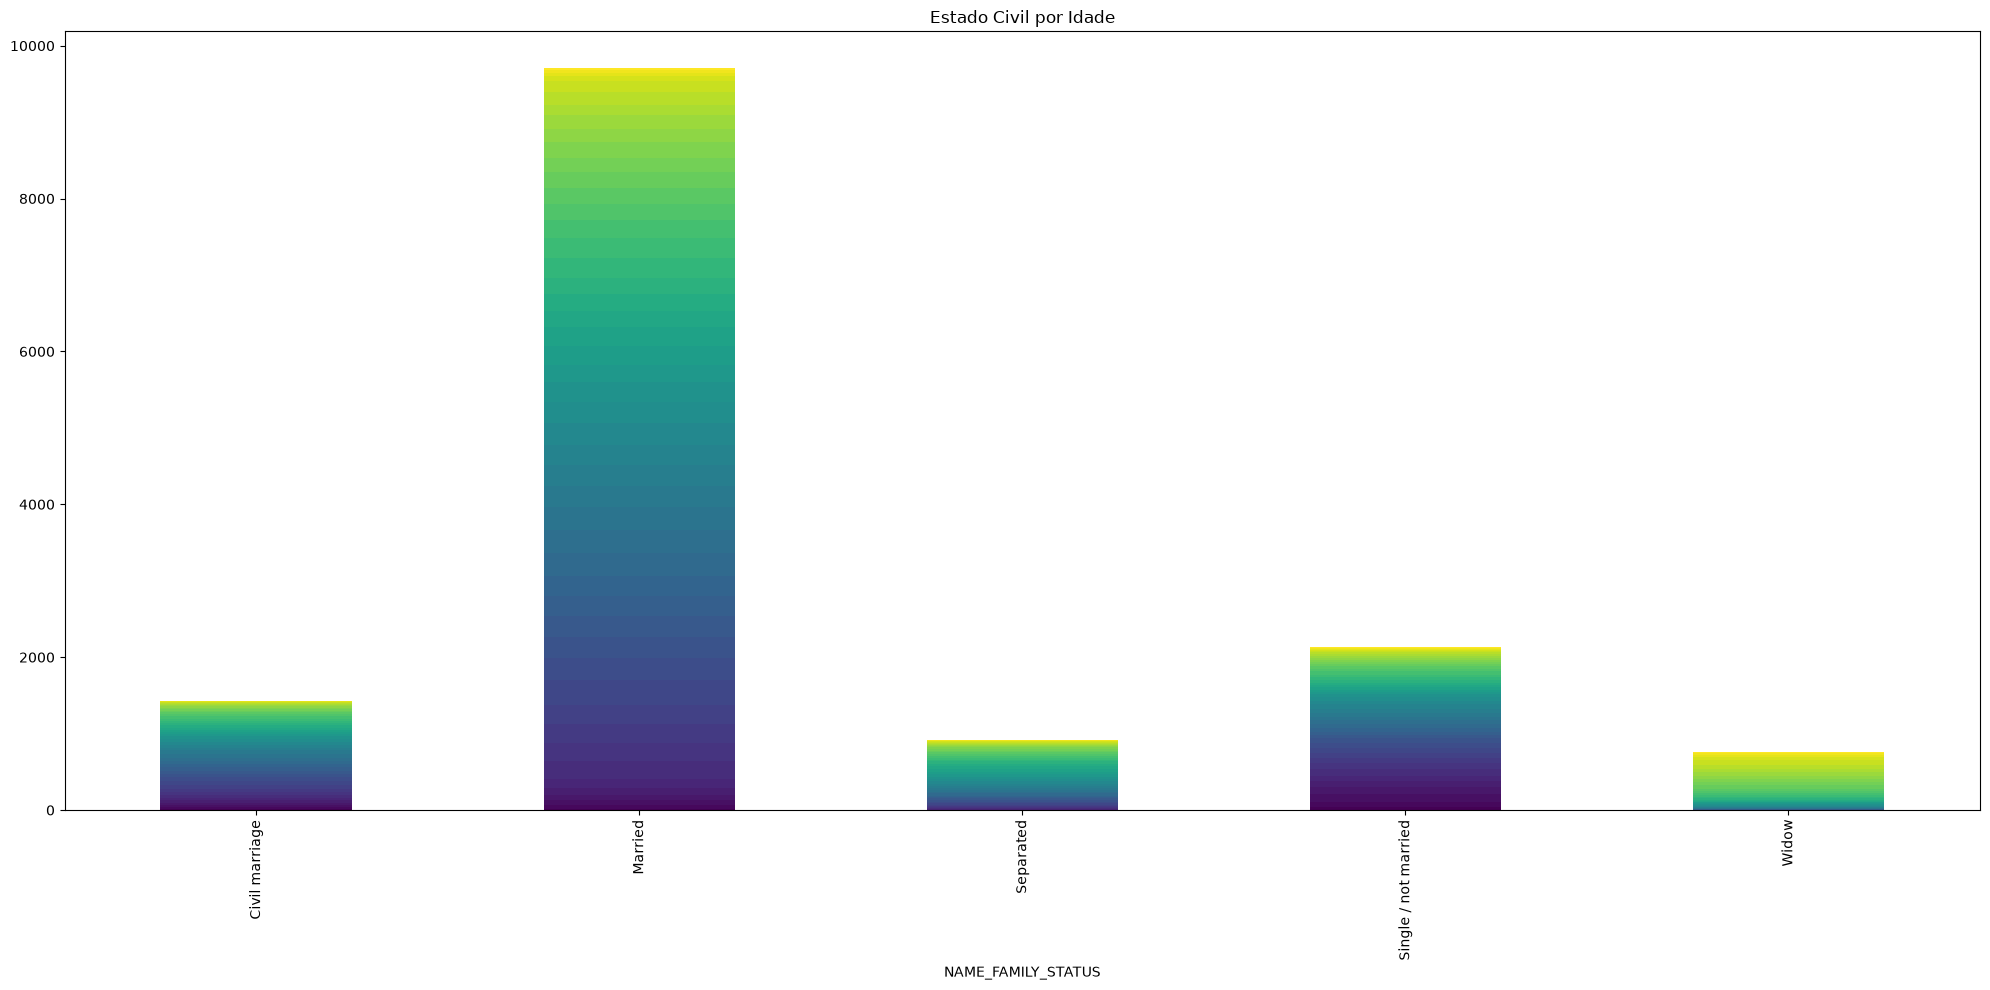

NAME_FAMILY_STATUS Civil marriage                                      ...  \
age                            21  22  23  24  25  26  27  28  29  30  ...   
CODE_GENDER                     8  32  30  27  35  20  46  41  41  46  ...   

NAME_FAMILY_STATUS Widow                                      
age                   59  60  61  62  63  64  65  66  67  68  
CODE_GENDER           37  46  40  48  51  60  37  29  31  12  

[1 rows x 228 columns]

In [189]:
# estado civil por idade 
plot_groupby(df_customers, 'NAME_FAMILY_STATUS', 'age', 'Estado Civil por Idade').agg_groupby('CODE_GENDER')

# Credit Balance

In [190]:
df_credit

,SK_ID_PREV,MONTHS_BALANCE,DURACAO_PARCELAS,PARCELAS_PENDENTES,NAME_CONTRACT_STATUS,DAYS_PAST_DUE,DAY_PAST_DUE_TOL,PARCELAS_PAGAS
0,1803195,-31,48.0,45.0,Active,0,0,3.0
1,1715348,-33,36.0,35.0,Active,0,0,1.0
2,1784872,-32,12.0,9.0,Active,0,0,3.0
3,1903291,-35,48.0,42.0,Active,0,0,6.0
4,2341044,-35,36.0,35.0,Active,0,0,1.0
...,...,...,...,...,...,...,...,...
14995,1320966,-19,24.0,20.0,Active,0,0,4.0
14996,2749827,-13,48.0,38.0,Active,0,0,10.0
14997,1045456,-16,60.0,60.0,Active,0,0,0.0
14998,1822563,-12,54.0,44.0,Active,0,0,10.0


In [191]:
# verificando dados nulos
df_credit.isnull().sum()

SK_ID_PREV               0
MONTHS_BALANCE           0
DURACAO_PARCELAS        24
PARCELAS_PENDENTES      24
NAME_CONTRACT_STATUS     0
DAYS_PAST_DUE            0
DAY_PAST_DUE_TOL         0
PARCELAS_PAGAS          24
dtype: int64

In [192]:
# dropando nulos
df_credit = df_credit.dropna()

In [193]:
df_credit['NAME_CONTRACT_STATUS'].value_counts()

NAME_CONTRACT_STATUS
Active                   13799
Completed                 1095
Signed                      69
Demand                       6
Approved                     5
Returned to the store        2
Name: count, dtype: int64

In [194]:
df_credit[df_credit['NAME_CONTRACT_STATUS']=='Returned to the store']

,SK_ID_PREV,MONTHS_BALANCE,DURACAO_PARCELAS,PARCELAS_PENDENTES,NAME_CONTRACT_STATUS,DAYS_PAST_DUE,DAY_PAST_DUE_TOL,PARCELAS_PAGAS
3953,1517510,-46,4.0,4.0,Returned to the store,0,0,0.0
5281,2117924,-47,4.0,4.0,Returned to the store,0,0,0.0


In [195]:
df_credit.info()

<class 'pandas.DataFrame'>
Index: 14976 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SK_ID_PREV            14976 non-null  int64  
 1   MONTHS_BALANCE        14976 non-null  int64  
 2   DURACAO_PARCELAS      14976 non-null  float64
 3   PARCELAS_PENDENTES    14976 non-null  float64
 4   NAME_CONTRACT_STATUS  14976 non-null  str    
 5   DAYS_PAST_DUE         14976 non-null  int64  
 6   DAY_PAST_DUE_TOL      14976 non-null  int64  
 7   PARCELAS_PAGAS        14976 non-null  float64
dtypes: float64(3), int64(4), str(1)
memory usage: 1.0 MB


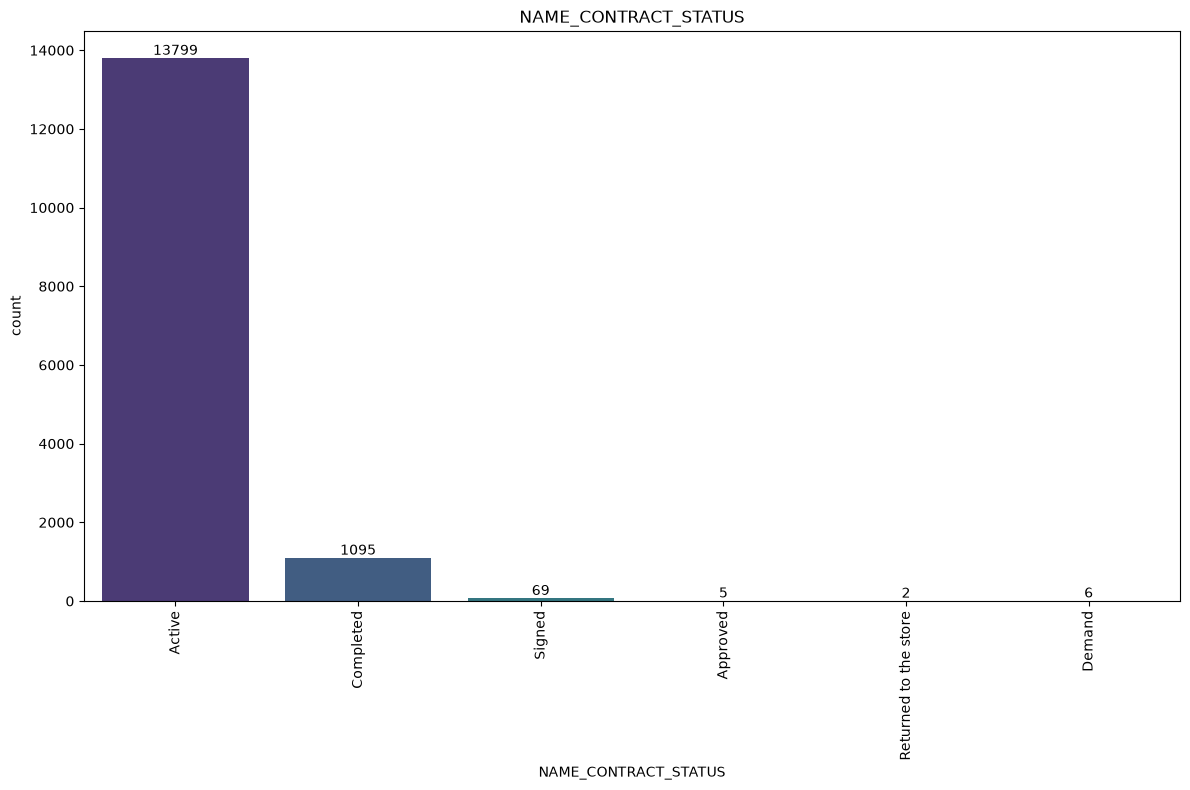

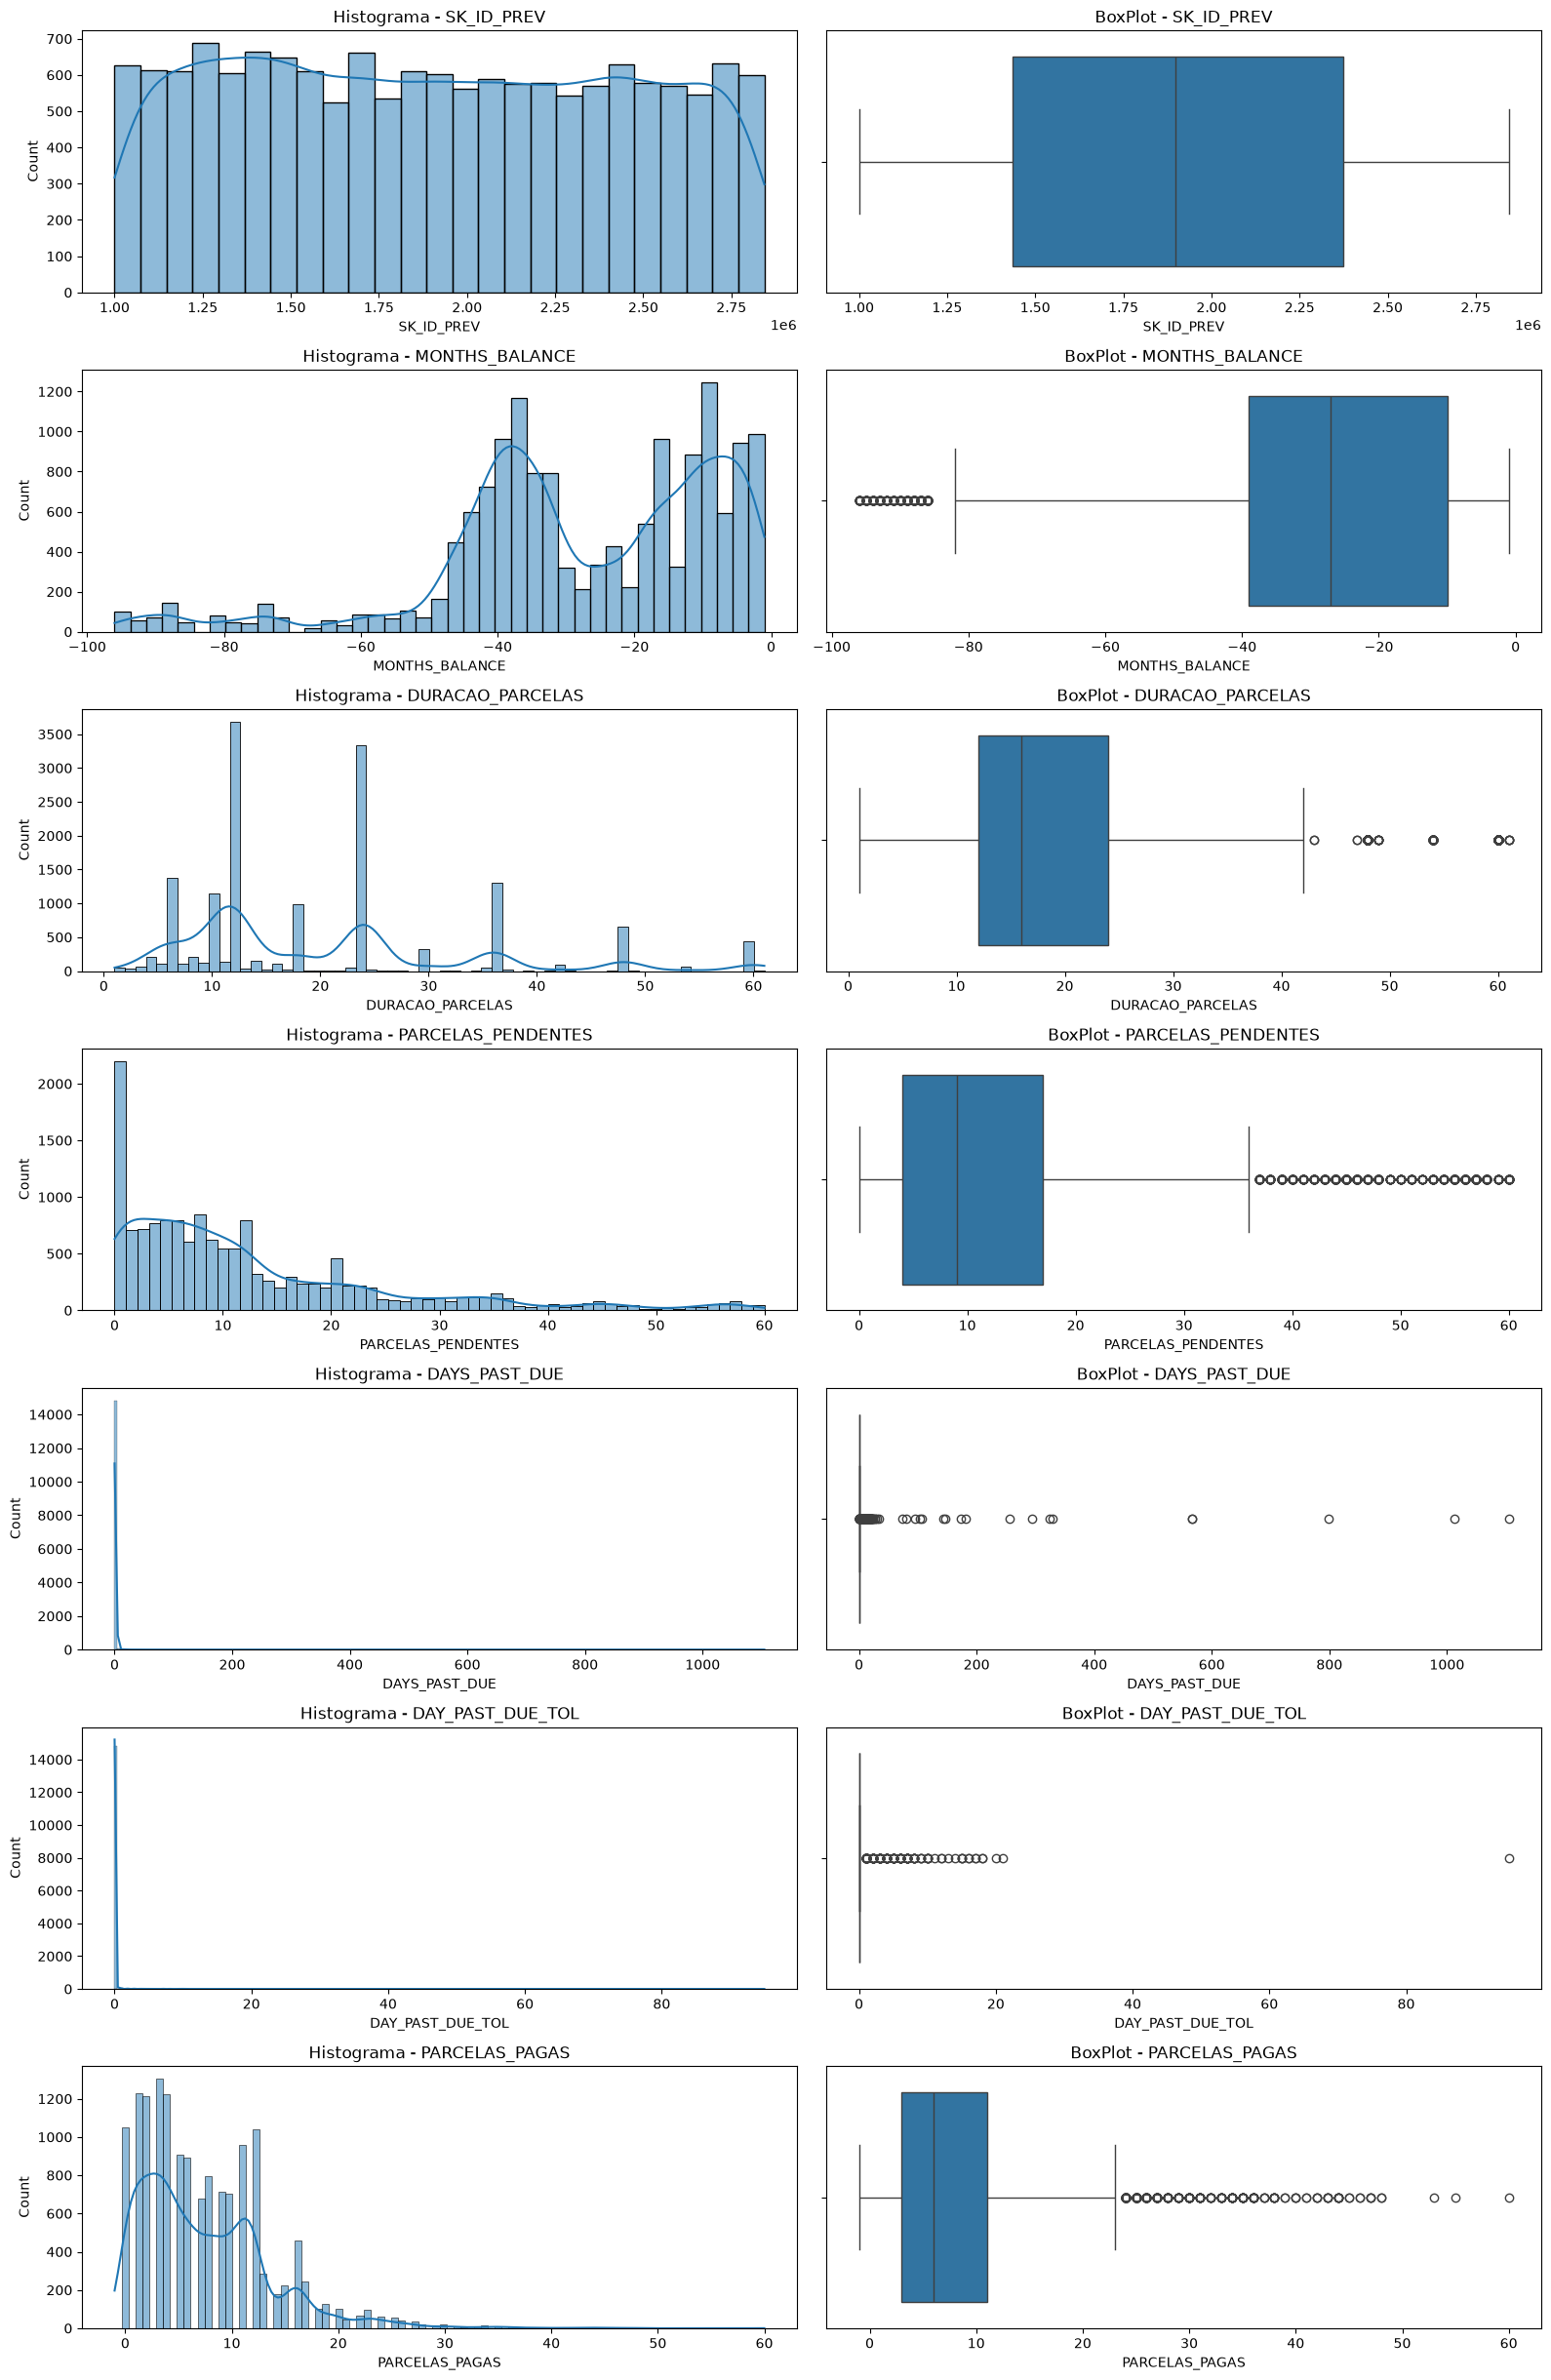

In [196]:
plot_cat_num_features(df_credit)

In [197]:
df_credit

,SK_ID_PREV,MONTHS_BALANCE,DURACAO_PARCELAS,PARCELAS_PENDENTES,NAME_CONTRACT_STATUS,DAYS_PAST_DUE,DAY_PAST_DUE_TOL,PARCELAS_PAGAS
0,1803195,-31,48.0,45.0,Active,0,0,3.0
1,1715348,-33,36.0,35.0,Active,0,0,1.0
2,1784872,-32,12.0,9.0,Active,0,0,3.0
3,1903291,-35,48.0,42.0,Active,0,0,6.0
4,2341044,-35,36.0,35.0,Active,0,0,1.0
...,...,...,...,...,...,...,...,...
14995,1320966,-19,24.0,20.0,Active,0,0,4.0
14996,2749827,-13,48.0,38.0,Active,0,0,10.0
14997,1045456,-16,60.0,60.0,Active,0,0,0.0
14998,1822563,-12,54.0,44.0,Active,0,0,10.0


desvio padrao: 4.283618741121396
mediana: 3.1449275362318843


NAME_CONTRACT_STATUS,Active,Approved,Completed,Demand,Returned to the store,Signed
PARCELAS_PAGAS,7.344953,0.0,9.558904,6.0,0.0,0.289855


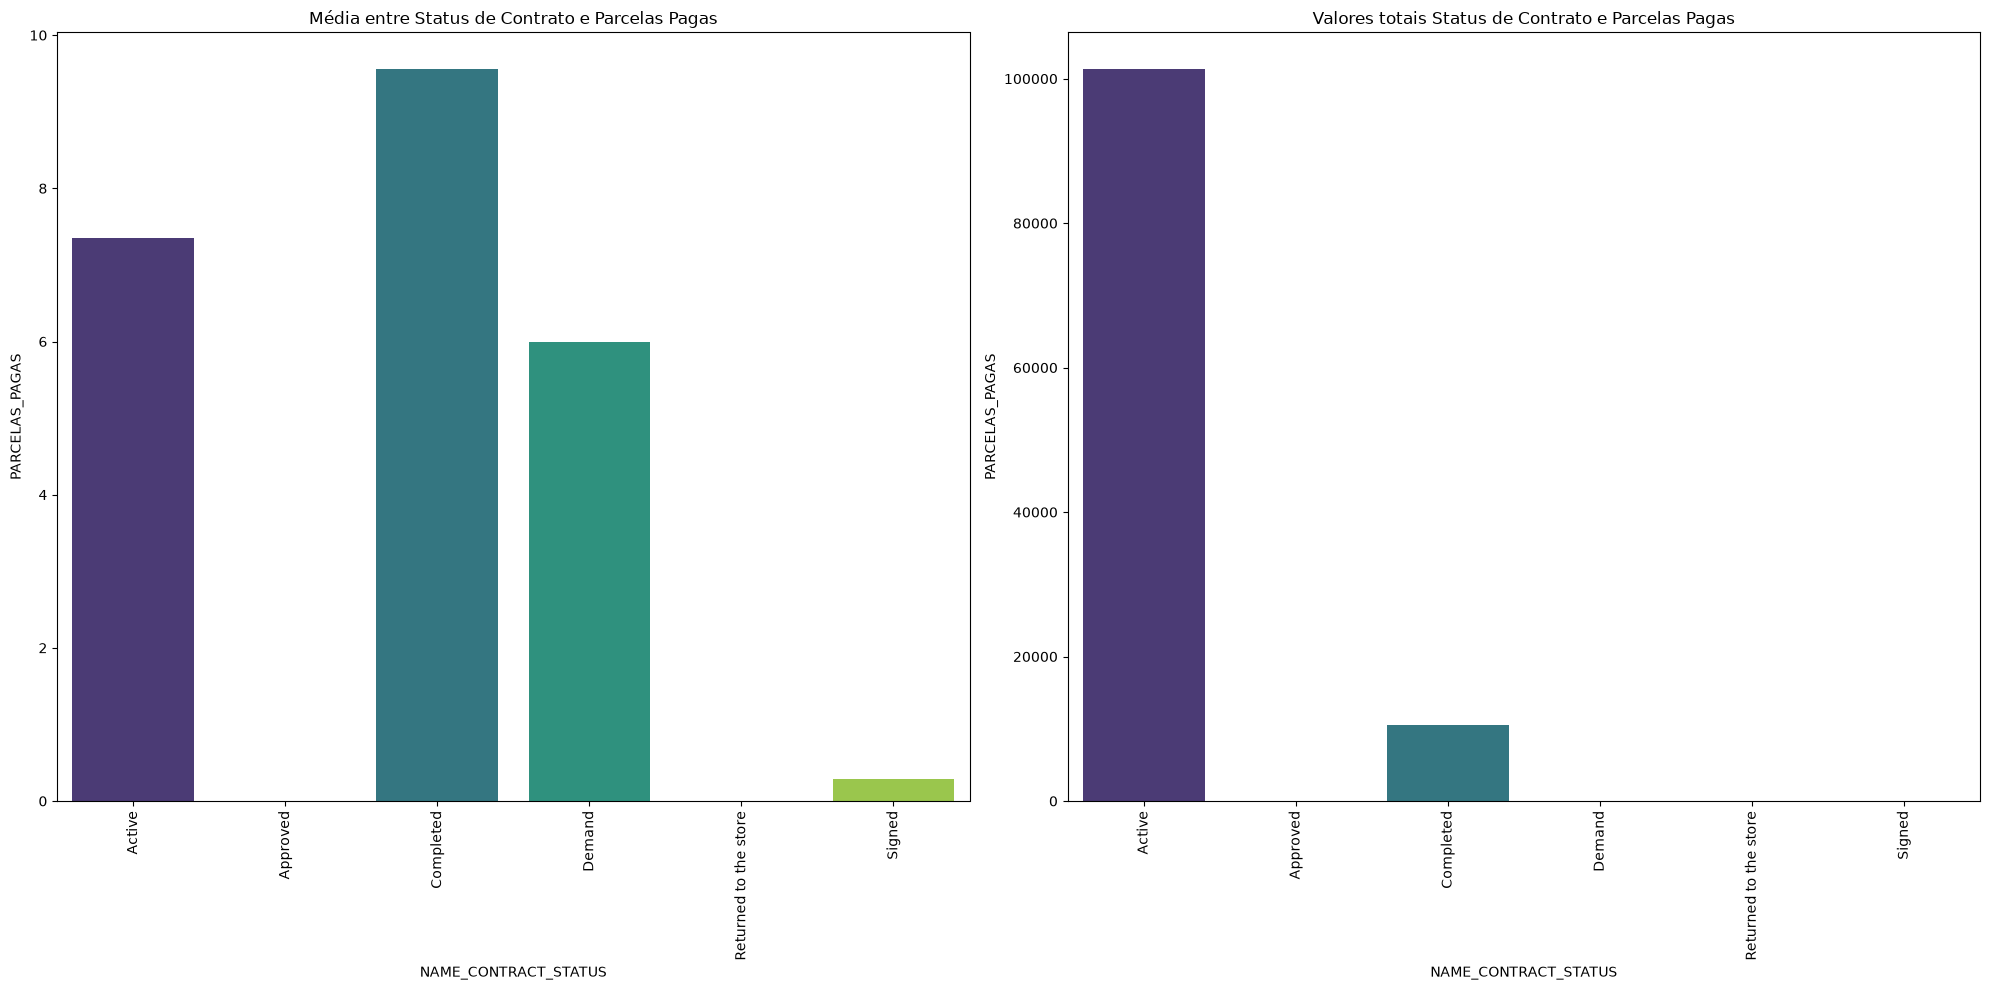

In [198]:
# status do contrato e parcelas pagas
plot_groupby(df_credit, 'NAME_CONTRACT_STATUS', 'PARCELAS_PAGAS', 'Status de Contrato e Parcelas Pagas').plot_mean()

desvio padrao: 13.130309926844044
mediana: 8.779150663091528


NAME_CONTRACT_STATUS,Active,Approved,Completed,Demand,Returned to the store,Signed
PARCELAS_PENDENTES,13.558301,33.6,0.0,0.0,4.0,18.478261


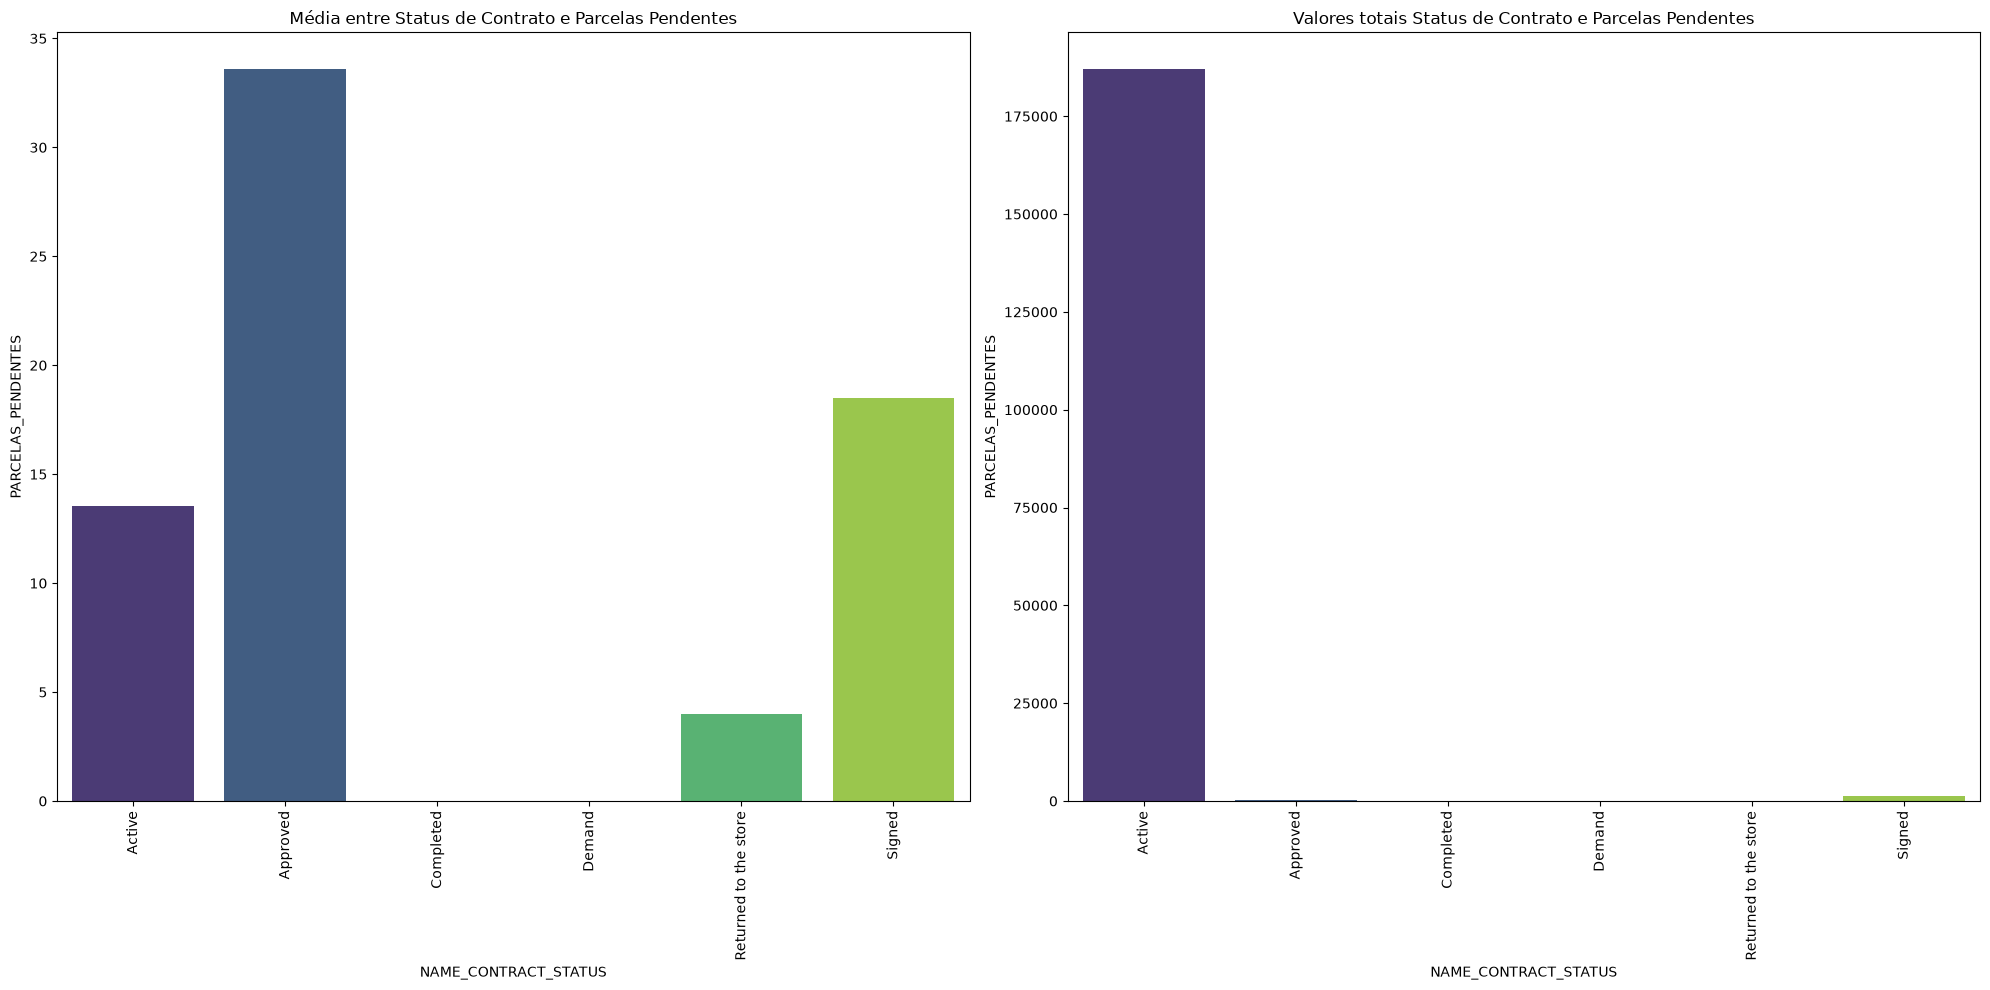

In [199]:
# status do contrado e parcelas pendentes
plot_groupby(df_credit, 'NAME_CONTRACT_STATUS', 'PARCELAS_PENDENTES', 'Status de Contrato e Parcelas Pendentes').plot_mean()

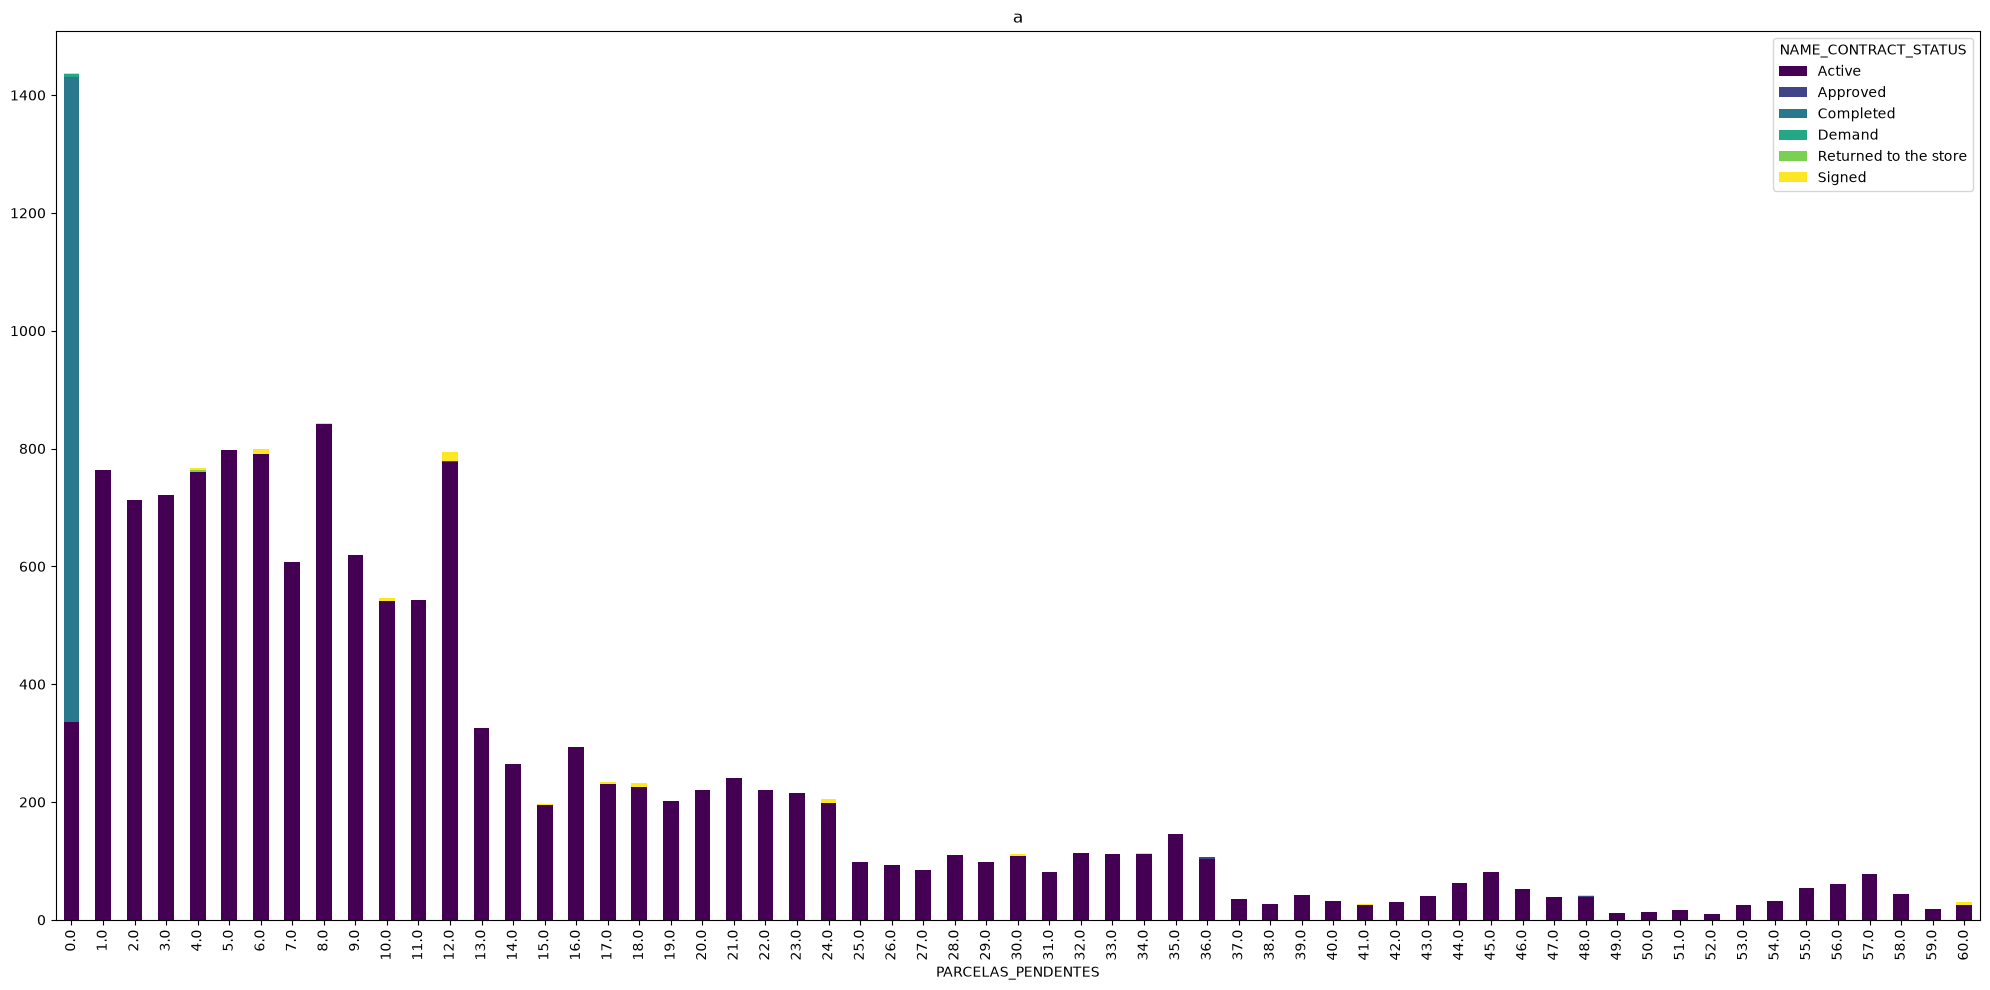

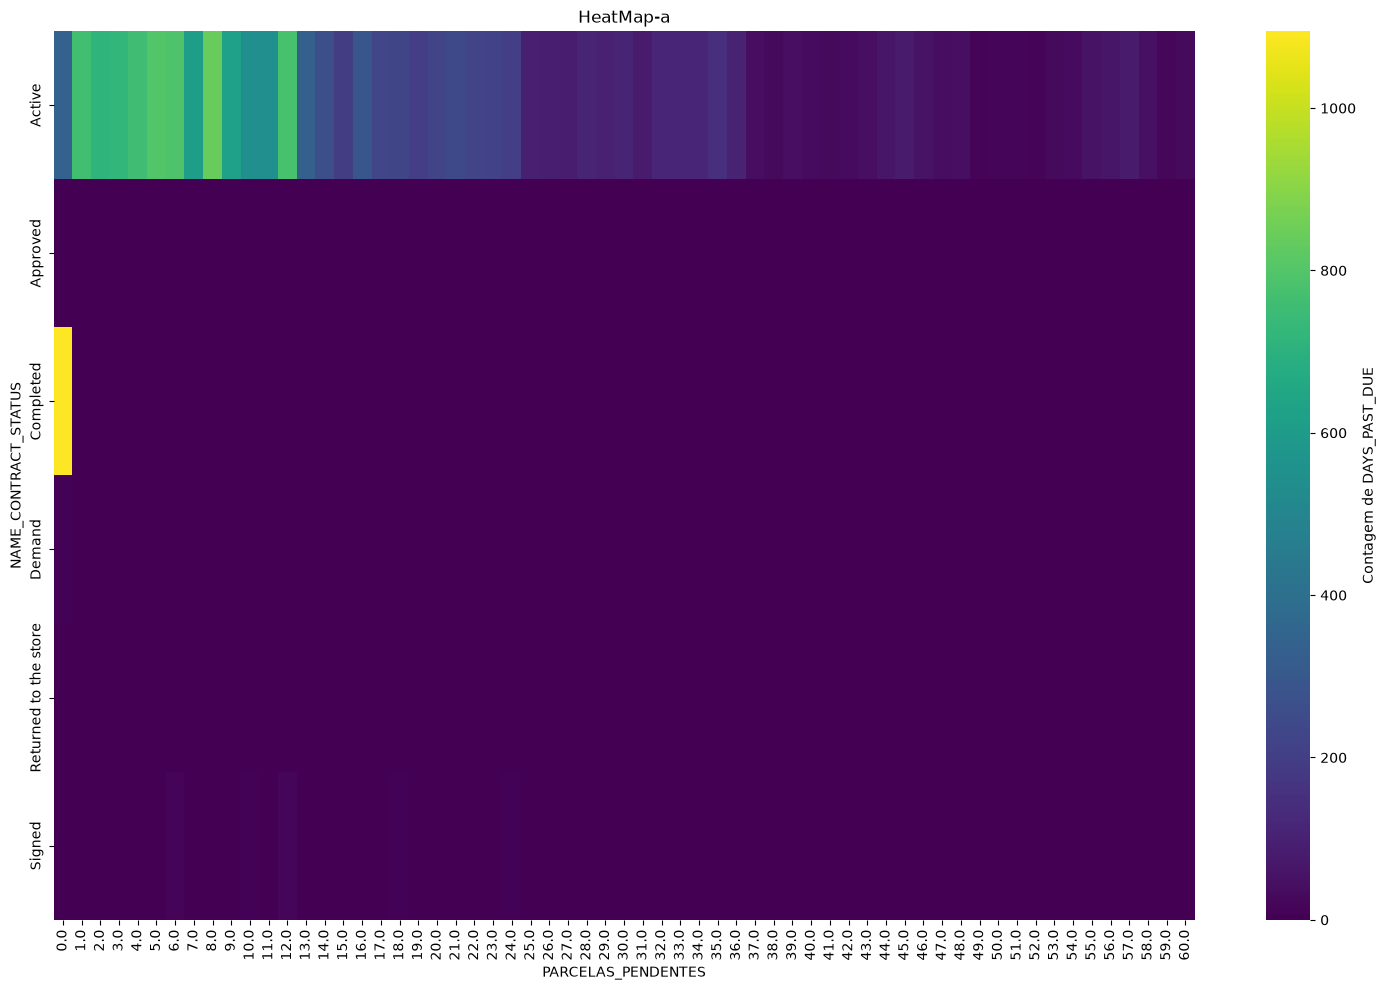

NAME_CONTRACT_STATUS Active                                               ...  \
PARCELAS_PENDENTES     0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0   ...   
DAYS_PAST_DUE           335  764  712  722  761  797  790  607  842  619  ...   

NAME_CONTRACT_STATUS Signed                                               
PARCELAS_PENDENTES     15.0 17.0 18.0 24.0 30.0 34.0 36.0 41.0 48.0 60.0  
DAYS_PAST_DUE             2    4    7    7    2    1    1    1    3    4  

[1 rows x 83 columns]

In [213]:
# tipo de contratos e quantidade de parcelas pendentes por dias de atraso
plot_groupby(df_credit, 'NAME_CONTRACT_STATUS', 'PARCELAS_PENDENTES', 'a').agg_groupby('DAYS_PAST_DUE')